In [1]:
# ============================================================
# NB2 - CELL 1
# MOUNT GOOGLE DRIVE / PROJECT PATHS
# ============================================================

from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Major_Project/Model/front_camera"
)

MODELS_DIR = PROJECT_DIR / "models"
CONFIG_DIR = PROJECT_DIR / "config"
SCRIPTS_DIR = PROJECT_DIR / "scripts"
DATA_DIR = PROJECT_DIR / "calibration_data"

print("=" * 75)
print("NB2 - FRONT CAMERA VALIDATION")
print("=" * 75)

print("Project :", PROJECT_DIR)
print("Models  :", MODELS_DIR)
print("Config  :", CONFIG_DIR)
print("Scripts :", SCRIPTS_DIR)

Mounted at /content/drive
NB2 - FRONT CAMERA VALIDATION
Project : /content/drive/MyDrive/Major_Project/Model/front_camera
Models  : /content/drive/MyDrive/Major_Project/Model/front_camera/models
Config  : /content/drive/MyDrive/Major_Project/Model/front_camera/config
Scripts : /content/drive/MyDrive/Major_Project/Model/front_camera/scripts


In [2]:
# ============================================================
# NB2 - CELL 2
# VERIFY SAVED ARTIFACTS
# ============================================================

required_files = [

    MODELS_DIR / "face_landmarker.task",

    MODELS_DIR / "pose_landmarker_full.task",

    CONFIG_DIR / "front_camera_calibration.json",

    CONFIG_DIR / "front_camera_distance_calibration.json",

    CONFIG_DIR / "front_camera_safety_config.json",

    SCRIPTS_DIR / "front_camera_pipeline.py",

    SCRIPTS_DIR / "requirements.txt"
]

print("=" * 75)
print("ARTIFACT VERIFICATION")
print("=" * 75)

missing = []

for path in required_files:

    exists = path.exists()

    print(
        f"{'✓' if exists else '❌'} "
        f"{path.relative_to(PROJECT_DIR)}"
    )

    if not exists:
        missing.append(path)

if missing:

    raise FileNotFoundError(
        "Missing artifacts:\n" +
        "\n".join(
            str(p)
            for p in missing
        )
    )

print(
    "\n✓ All required artifacts found."
)

ARTIFACT VERIFICATION
✓ models/face_landmarker.task
✓ models/pose_landmarker_full.task
✓ config/front_camera_calibration.json
✓ config/front_camera_distance_calibration.json
✓ config/front_camera_safety_config.json
✓ scripts/front_camera_pipeline.py
✓ scripts/requirements.txt

✓ All required artifacts found.


In [3]:
# ============================================================
# NB2 - CELL 3
# DEPENDENCIES
# ============================================================

!pip install -q mediapipe opencv-python numpy pandas scipy matplotlib

import sys
import json
import time
import base64
import importlib.util

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp

print("=" * 75)
print("ENVIRONMENT")
print("=" * 75)

print("Python     :", sys.version.split()[0])
print("OpenCV     :", cv2.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("MediaPipe  :", mp.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.8 MB/s eta 0:00:00
ENVIRONMENT
Python     : 3.12.13
OpenCV     : 5.0.0
NumPy      : 2.0.2
Pandas     : 2.2.2
MediaPipe  : 1.0.0


In [4]:
# ============================================================
# NB2 - CELL 4
# LOAD SAVED FRONT CAMERA PIPELINE
# ============================================================

PIPELINE_FILE = (
    SCRIPTS_DIR /
    "front_camera_pipeline.py"
)

spec = importlib.util.spec_from_file_location(
    "front_camera_pipeline",
    PIPELINE_FILE
)

front_camera_module = (
    importlib.util.module_from_spec(spec)
)

spec.loader.exec_module(
    front_camera_module
)

FrontCameraPipeline = (
    front_camera_module.FrontCameraPipeline
)

print("=" * 75)
print("PIPELINE MODULE")
print("=" * 75)

print(
    "Loaded:",
    PIPELINE_FILE
)

print(
    "Class:",
    FrontCameraPipeline
)

PIPELINE MODULE
Loaded: /content/drive/MyDrive/Major_Project/Model/front_camera/scripts/front_camera_pipeline.py
Class: <class 'front_camera_pipeline.FrontCameraPipeline'>


In [5]:
# ============================================================
# NB2 - CELL 5
# INITIALIZE PIPELINE FROM SAVED ARTIFACTS
# ============================================================

pipeline = FrontCameraPipeline(
    model_dir=MODELS_DIR,
    config_dir=CONFIG_DIR
)

print("=" * 75)
print("FRONT CAMERA PIPELINE INITIALIZED")
print("=" * 75)

print("Face model : loaded")
print("Pose model : loaded")
print("Calibration: loaded")
print("Safety cfg : loaded")

print("\n✓ Pipeline ready")

FRONT CAMERA PIPELINE INITIALIZED
Face model : loaded
Pose model : loaded
Calibration: loaded
Safety cfg : loaded

✓ Pipeline ready


In [6]:
# ============================================================
# NB2 - CELL 6
# INSPECT LOADED CONFIGURATION
# ============================================================

print("=" * 75)
print("DISTANCE POLICY")
print("=" * 75)

print(
    json.dumps(
        pipeline.distance_policy,
        indent=2
    )
)

print("\n" + "=" * 75)
print("REFERENCE PROFILE")
print("=" * 75)

for key, value in (
    pipeline.reference.items()
):

    if isinstance(
        value,
        (int, float)
    ):

        print(
            f"{key:<35}: {value:.5f}"
        )

DISTANCE POLICY
{
  "non_safe_min_cm": 40.0,
  "safe_min_cm": 45.0,
  "safe_max_cm": 75.0,
  "non_safe_max_cm": 85.0
}

REFERENCE PROFILE
timestamp                          : 1786547885.00264
left_eye_open_ratio                : 0.46130
right_eye_open_ratio               : 0.46106
mean_eye_open_ratio                : 0.45684
mean_gaze_x                        : 0.51335
mean_gaze_y                        : 0.42050
face_width_norm                    : 0.13392
face_height_norm                   : 0.26755
face_center_x                      : 0.52372
face_center_y                      : 0.71714
head_pitch_deg                     : -5.89107
head_yaw_deg                       : -2.22621
head_roll_deg                      : 1.06948
shoulder_width                     : 0.31304
shoulder_tilt_deg                  : -0.58973
shoulder_height_difference         : 0.00386
shoulder_alignment_ratio           : 0.01232
head_offset_x                      : -0.01330
head_offset_y                      : -0

In [7]:
# ============================================================
# NB2 - CELL 7
# ROBUST SINGLE WEBCAM FRAME CAPTURE
# ============================================================

from google.colab import output


def capture_webcam_frame():

    js_code = r"""
    (async () => {

        const video =
            document.createElement("video");

        video.setAttribute(
            "autoplay",
            ""
        );

        video.setAttribute(
            "playsinline",
            ""
        );

        video.muted = true;

        video.style.position = "fixed";
        video.style.left = "-10000px";
        video.style.top = "-10000px";
        video.style.width = "1px";
        video.style.height = "1px";

        document.body.appendChild(video);

        let stream = null;

        try {

            stream =
                await navigator.mediaDevices.getUserMedia({
                    video: {
                        facingMode: "user",
                        width: { ideal: 1280 },
                        height: { ideal: 720 }
                    },
                    audio: false
                });

            video.srcObject = stream;

            await video.play();

            await new Promise(resolve => {

                if (
                    video.videoWidth > 0 &&
                    video.videoHeight > 0
                ) {
                    resolve();
                    return;
                }

                video.onloadedmetadata =
                    () => resolve();
            });

            await new Promise(
                resolve =>
                setTimeout(resolve, 300)
            );

            const canvas =
                document.createElement("canvas");

            canvas.width =
                video.videoWidth;

            canvas.height =
                video.videoHeight;

            const ctx =
                canvas.getContext("2d");

            ctx.drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

            return canvas.toDataURL(
                "image/jpeg",
                0.85
            );

        } finally {

            if (stream !== null) {

                stream
                    .getTracks()
                    .forEach(
                        track =>
                        track.stop()
                    );
            }

            video.remove();
        }
    })()
    """

    encoded = output.eval_js(
        js_code
    )

    _, encoded_data = (
        encoded.split(",", 1)
    )

    image_bytes = (
        base64.b64decode(
            encoded_data
        )
    )

    image_array = np.frombuffer(
        image_bytes,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        image_array,
        cv2.IMREAD_COLOR
    )

    if frame is None:
        raise RuntimeError(
            "Could not decode webcam frame."
        )

    return frame

In [9]:
# ============================================================
# NB2 - CELL 8
# FIRST SAVED-PIPELINE CAMERA TEST
# ============================================================

print("=" * 75)
print("NB2 - SINGLE FRAME PIPELINE TEST")
print("=" * 75)

frame = capture_webcam_frame()

print(
    "Frame shape:",
    frame.shape
)

result = pipeline.process_frame(
    frame
)

print("\n" + "=" * 75)
print("PIPELINE OUTPUT")
print("=" * 75)

for key, value in result.items():

    if isinstance(
        value,
        (float, int, np.number)
    ):

        print(
            f"{key:<35}: "
            f"{float(value):.4f}"
        )

    else:

        print(
            f"{key:<35}: "
            f"{value}"
        )

NB2 - SINGLE FRAME PIPELINE TEST
Frame shape: (720, 1280, 3)

PIPELINE OUTPUT
timestamp                          : 1786552669.6448
face_detected                      : 1.0000
pose_detected                      : 1.0000
status                             : UNKNOWN
left_eye_open_ratio                : 0.5200
right_eye_open_ratio               : 0.5476
mean_eye_open_ratio                : 0.5338
face_width_norm                    : 0.1373
estimated_distance_cm              : 60.2967
blink_count                        : 0.0000
head_pitch_deg                     : 0.6397
head_yaw_deg                       : 2.2569
head_roll_deg                      : 3.4567
shoulder_width                     : 0.3373
shoulder_tilt_deg                  : 5.6724
shoulder_alignment_ratio           : 0.0988
head_offset_x                      : -0.0211
head_offset_y                      : -0.2953
frame_status                       : SAFE
violations                         : []


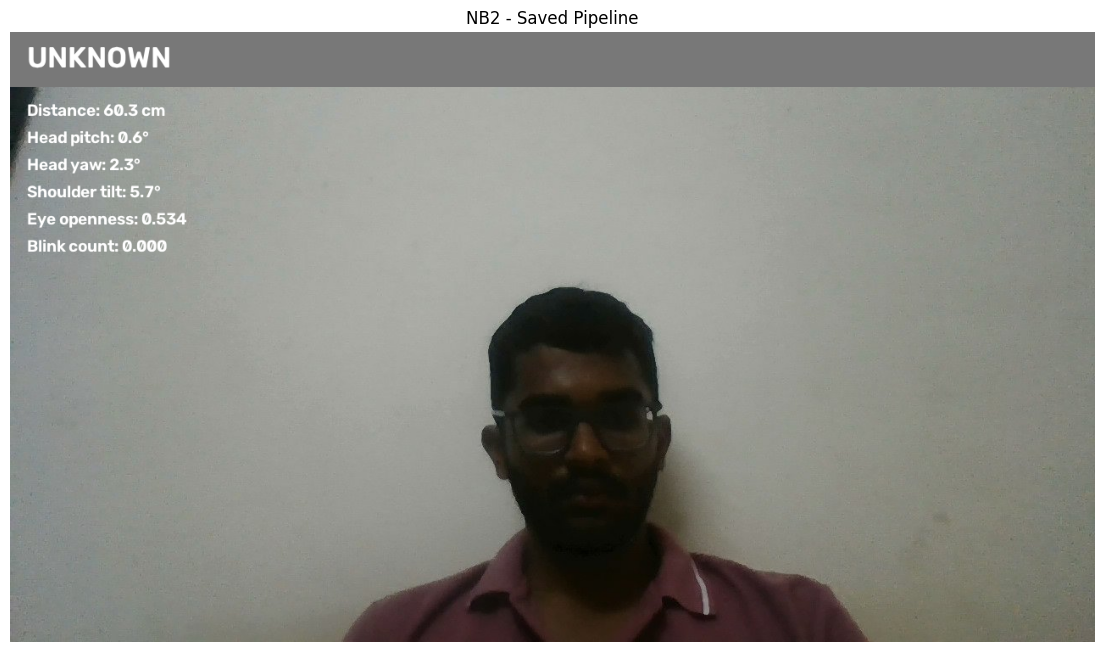

In [10]:
# ============================================================
# NB2 - CELL 9
# ANNOTATED SINGLE FRAME
# ============================================================

annotated = frame.copy()

status = result.get(
    "status",
    result.get(
        "frame_status",
        "UNKNOWN"
    )
)

if status == "SAFE":

    color = (
        40,
        180,
        40
    )

elif status == "WARNING":

    color = (
        0,
        180,
        255
    )

elif status == "NON-SAFE":

    color = (
        0,
        0,
        220
    )

else:

    color = (
        120,
        120,
        120
    )


# Header
cv2.rectangle(
    annotated,
    (0, 0),
    (annotated.shape[1], 65),
    color,
    -1
)

cv2.putText(
    annotated,
    str(status),
    (20, 43),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.2,
    (255, 255, 255),
    3,
    cv2.LINE_AA
)


# Measurements
display_values = [

    (
        "Distance",
        result.get(
            "estimated_distance_cm",
            np.nan
        ),
        "cm"
    ),

    (
        "Head pitch",
        result.get(
            "head_pitch_deg",
            np.nan
        ),
        "deg"
    ),

    (
        "Head yaw",
        result.get(
            "head_yaw_deg",
            np.nan
        ),
        "deg"
    ),

    (
        "Shoulder tilt",
        result.get(
            "shoulder_tilt_deg",
            np.nan
        ),
        "deg"
    ),

    (
        "Eye openness",
        result.get(
            "mean_eye_open_ratio",
            np.nan
        ),
        ""
    ),

    (
        "Blink count",
        result.get(
            "blink_count",
            0
        ),
        ""
    )
]

y = 100

for name, value, unit in display_values:

    if pd.isna(value):

        text = f"{name}: unavailable"

    elif unit == "cm":

        text = (
            f"{name}: "
            f"{float(value):.1f} cm"
        )

    elif unit == "deg":

        text = (
            f"{name}: "
            f"{float(value):.1f}°"
        )

    else:

        text = (
            f"{name}: "
            f"{float(value):.3f}"
        )

    cv2.putText(
        annotated,
        text,
        (20, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    y += 32


plt.figure(
    figsize=(14, 8)
)

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title(
    "NB2 - Saved Pipeline"
)

plt.show()

In [11]:
# ============================================================
# NB2 - CELL 10
# CAPTURE CONTINUOUS VIDEO SEQUENCE
# ============================================================

def capture_video_sequence(
    seconds=10,
    fps=5
):

    frame_count = int(
        seconds * fps
    )

    delay_ms = int(
        1000 / fps
    )

    js_code = f"""
    (async () => {{

        const video =
            document.createElement("video");

        video.setAttribute(
            "autoplay",
            ""
        );

        video.setAttribute(
            "playsinline",
            ""
        );

        video.muted = true;

        video.style.position = "fixed";
        video.style.right = "10px";
        video.style.bottom = "10px";
        video.style.width = "320px";
        video.style.height = "180px";
        video.style.zIndex = "99999";
        video.style.border = "3px solid white";

        document.body.appendChild(video);

        let stream = null;

        try {{

            stream =
                await navigator.mediaDevices.getUserMedia({{
                    video: {{
                        facingMode: "user",
                        width: {{ ideal: 1280 }},
                        height: {{ ideal: 720 }}
                    }},
                    audio: false
                }});

            video.srcObject = stream;

            await video.play();

            await new Promise(resolve => {{

                if (
                    video.videoWidth > 0 &&
                    video.videoHeight > 0
                ) {{
                    resolve();
                    return;
                }}

                video.onloadedmetadata =
                    () => resolve();
            }});

            const canvas =
                document.createElement("canvas");

            canvas.width =
                video.videoWidth;

            canvas.height =
                video.videoHeight;

            const ctx =
                canvas.getContext("2d");

            const frames = [];

            for (
                let i = 0;
                i < {frame_count};
                i++
            ) {{

                ctx.drawImage(
                    video,
                    0,
                    0,
                    canvas.width,
                    canvas.height
                );

                frames.push(
                    canvas.toDataURL(
                        "image/jpeg",
                        0.75
                    )
                );

                await new Promise(
                    resolve =>
                    setTimeout(
                        resolve,
                        {delay_ms}
                    )
                );
            }}

            return frames;

        }} finally {{

            if (stream !== null) {{

                stream
                    .getTracks()
                    .forEach(
                        track =>
                        track.stop()
                    );
            }}

            video.remove();
        }}

    }})()
    """

    encoded_frames = output.eval_js(
        js_code
    )

    frames = []

    for encoded in encoded_frames:

        _, encoded_data = (
            encoded.split(",", 1)
        )

        image_bytes = (
            base64.b64decode(
                encoded_data
            )
        )

        image_array = np.frombuffer(
            image_bytes,
            dtype=np.uint8
        )

        frame = cv2.imdecode(
            image_array,
            cv2.IMREAD_COLOR
        )

        if frame is not None:
            frames.append(frame)

    return frames


print("=" * 75)
print("VIDEO CAPTURE")
print("=" * 75)

print(
    "Duration : 10 seconds"
)

print(
    "Inference sample rate : 5 FPS"
)

video_frames = capture_video_sequence(
    seconds=10,
    fps=5
)

print(
    "\nFrames captured:",
    len(video_frames)
)

VIDEO CAPTURE
Duration : 10 seconds
Inference sample rate : 5 FPS

Frames captured: 50


In [12]:
# ============================================================
# NB2 - CELL 11
# PROCESS VIDEO THROUGH SAVED PIPELINE
# ============================================================

print("=" * 75)
print("PROCESSING VIDEO")
print("=" * 75)

video_results = []

start_time = time.time()

for i, frame in enumerate(
    video_frames
):

    frame_time = (
        start_time +
        i * 0.2
    )

    result = pipeline.process_frame(
        frame
    )

    result["frame_id"] = i + 1

    result["time_sec"] = (
        i * 0.2
    )

    video_results.append(
        result
    )


video_df = pd.DataFrame(
    video_results
)

print(
    "Processed:",
    len(video_df),
    "frames"
)

display(
    video_df[
        [
            "frame_id",
            "time_sec",
            "estimated_distance_cm",
            "head_pitch_deg",
            "head_yaw_deg",
            "head_roll_deg",
            "shoulder_tilt_deg",
            "mean_eye_open_ratio",
            "blink_count",
            "status"
        ]
    ].round(3)
)

PROCESSING VIDEO
Processed: 50 frames


,frame_id,time_sec,estimated_distance_cm,head_pitch_deg,head_yaw_deg,head_roll_deg,shoulder_tilt_deg,mean_eye_open_ratio,blink_count,status
0,1,0.0,54.384,3.633,-3.153,5.028,5.987,0.520,0,UNKNOWN
1,2,0.2,55.266,4.770,-1.242,4.037,4.598,0.483,0,UNKNOWN
2,3,0.4,54.195,6.663,0.627,1.794,4.973,0.550,0,UNKNOWN
3,4,0.6,55.205,8.481,-0.153,3.499,5.110,0.540,0,UNKNOWN
4,5,0.8,55.311,8.820,-0.832,1.078,2.253,0.401,0,UNKNOWN
5,6,1.0,55.589,7.738,0.177,0.136,2.422,0.519,0,UNKNOWN
6,7,1.2,55.956,6.304,-1.386,1.682,2.343,0.560,0,UNKNOWN
7,8,1.4,55.225,7.448,-1.934,2.352,2.198,0.601,0,UNKNOWN
8,9,1.6,55.061,9.553,-3.097,2.588,3.910,0.514,0,UNKNOWN
9,10,1.8,56.194,6.238,-2.631,2.902,2.864,0.338,0,UNKNOWN


In [13]:
# ============================================================
# NB2 - CELL 12
# VIDEO MEASUREMENT STABILITY
# ============================================================

print("=" * 75)
print("VIDEO MEASUREMENT STABILITY")
print("=" * 75)

stability_features = [

    "estimated_distance_cm",

    "head_pitch_deg",

    "head_yaw_deg",

    "head_roll_deg",

    "shoulder_tilt_deg",

    "mean_eye_open_ratio"
]

stability_rows = []

for feature in stability_features:

    if feature not in video_df.columns:
        continue

    values = (
        pd.to_numeric(
            video_df[feature],
            errors="coerce"
        )
        .dropna()
        .to_numpy()
    )

    if len(values) == 0:
        continue

    stability_rows.append({

        "feature":
            feature,

        "mean":
            np.mean(values),

        "std":
            np.std(values),

        "minimum":
            np.min(values),

        "maximum":
            np.max(values),

        "range":
            np.ptp(values)
    })


stability_df = pd.DataFrame(
    stability_rows
)

display(
    stability_df.round(4)
)

VIDEO MEASUREMENT STABILITY


,feature,mean,std,minimum,maximum,range
0,estimated_distance_cm,54.4406,2.2584,49.2673,57.5498,8.2825
1,head_pitch_deg,-1.2606,7.8668,-18.9248,9.5531,28.4779
2,head_yaw_deg,7.7302,17.7850,-15.4681,46.0711,61.5392
3,head_roll_deg,16.7438,17.4503,0.1361,51.8291,51.6930
4,shoulder_tilt_deg,6.1371,3.4812,0.4843,11.9299,11.4456
5,mean_eye_open_ratio,0.4292,0.1271,0.1929,0.6828,0.4899


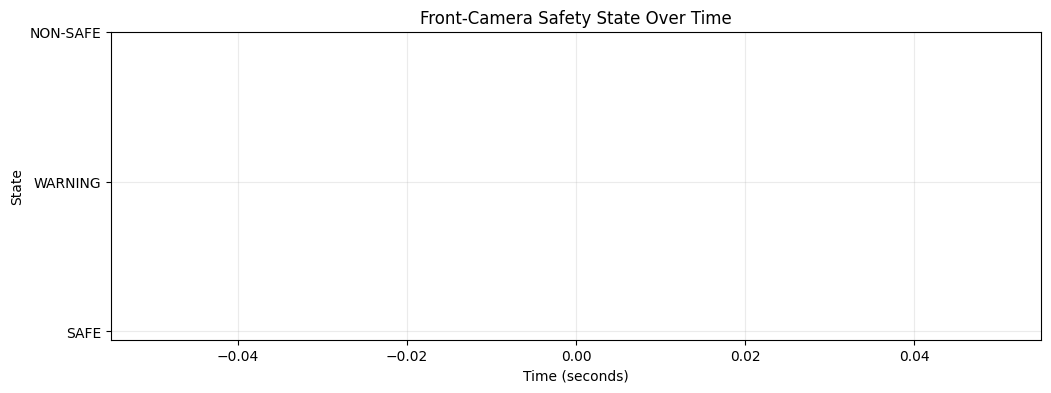

In [14]:
# ============================================================
# NB2 - CELL 13
# STATUS TIMELINE
# ============================================================

status_order = {
    "SAFE": 0,
    "WARNING": 1,
    "NON-SAFE": 2,
    "UNKNOWN": np.nan
}

video_df[
    "status_numeric"
] = video_df[
    "status"
].map(
    status_order
)

plt.figure(
    figsize=(12, 4)
)

plt.step(
    video_df["time_sec"],
    video_df["status_numeric"],
    where="post"
)

plt.yticks(
    [0, 1, 2],
    [
        "SAFE",
        "WARNING",
        "NON-SAFE"
    ]
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "State"
)

plt.title(
    "Front-Camera Safety State Over Time"
)

plt.grid(
    alpha=0.25
)

plt.show()

BLINK ANALYSIS
Initial blink count: 0
Final blink count: 1
Blinks detected during sequence: 1


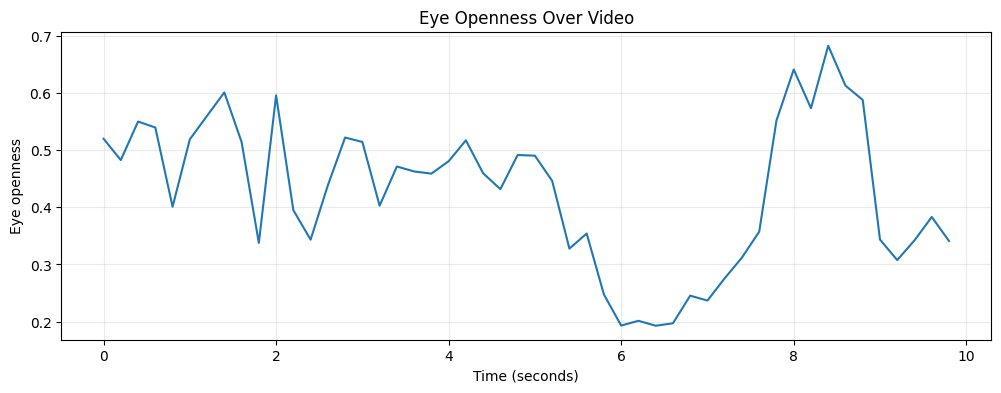

In [15]:
# ============================================================
# NB2 - CELL 14
# BLINK ANALYSIS
# ============================================================

print("=" * 75)
print("BLINK ANALYSIS")
print("=" * 75)

print(
    "Initial blink count:",
    video_df[
        "blink_count"
    ].iloc[0]
)

print(
    "Final blink count:",
    video_df[
        "blink_count"
    ].iloc[-1]
)

print(
    "Blinks detected during sequence:",
    (
        video_df[
            "blink_count"
        ].max()
        -
        video_df[
            "blink_count"
        ].min()
    )
)

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    video_df["time_sec"],
    video_df["mean_eye_open_ratio"]
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Eye openness"
)

plt.title(
    "Eye Openness Over Video"
)

plt.grid(
    alpha=0.25
)

plt.show()

In [16]:
# ============================================================
# NB2 - CELL 15
# SAVE VIDEO VALIDATION RESULTS
# ============================================================

NB2_RESULTS_DIR = (
    DATA_DIR /
    "nb2_validation"
)

NB2_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VIDEO_RESULTS_FILE = (
    NB2_RESULTS_DIR /
    "video_validation_results.csv"
)

STABILITY_FILE = (
    NB2_RESULTS_DIR /
    "measurement_stability.csv"
)

video_df.to_csv(
    VIDEO_RESULTS_FILE,
    index=False
)

stability_df.to_csv(
    STABILITY_FILE,
    index=False
)

print("=" * 75)
print("NB2 RESULTS SAVED")
print("=" * 75)

print(
    VIDEO_RESULTS_FILE
)

print(
    STABILITY_FILE
)

NB2 RESULTS SAVED
/content/drive/MyDrive/Major_Project/Model/front_camera/calibration_data/nb2_validation/video_validation_results.csv
/content/drive/MyDrive/Major_Project/Model/front_camera/calibration_data/nb2_validation/measurement_stability.csv


In [17]:
# ============================================================
# NB2 - CELL 16
# PATCH SAVED PIPELINE STATUS OUTPUT
# ============================================================

pipeline_path = (
    SCRIPTS_DIR /
    "front_camera_pipeline.py"
)

with open(
    pipeline_path,
    "r"
) as f:
    pipeline_source = f.read()


old_code = '''        result[
            "frame_status"
        ] = frame_status

        result[
            "violations"
        ] = violations

        return result
'''


new_code = '''        result[
            "frame_status"
        ] = frame_status

        # Public status field used by the validation notebook
        result[
            "status"
        ] = frame_status

        result[
            "violations"
        ] = violations

        return result
'''


if old_code not in pipeline_source:

    print(
        "⚠ Expected code block was not found."
    )

    print(
        "The pipeline may already contain the fix."
    )

else:

    pipeline_source = pipeline_source.replace(
        old_code,
        new_code
    )

    with open(
        pipeline_path,
        "w"
    ) as f:

        f.write(
            pipeline_source
        )

    print(
        "✓ Pipeline patched."
    )

print(
    "\nPipeline:",
    pipeline_path
)

✓ Pipeline patched.

Pipeline: /content/drive/MyDrive/Major_Project/Model/front_camera/scripts/front_camera_pipeline.py


In [18]:
# ============================================================
# NB2 - CELL 17
# RELOAD PATCHED PIPELINE
# ============================================================

import importlib.util

spec = importlib.util.spec_from_file_location(
    "front_camera_pipeline_v2",
    PIPELINE_FILE
)

front_camera_module_v2 = (
    importlib.util.module_from_spec(
        spec
    )
)

spec.loader.exec_module(
    front_camera_module_v2
)

FrontCameraPipeline = (
    front_camera_module_v2.FrontCameraPipeline
)

# Reinitialize
pipeline = FrontCameraPipeline(
    model_dir=MODELS_DIR,
    config_dir=CONFIG_DIR
)

print(
    "✓ Patched pipeline loaded."
)

✓ Patched pipeline loaded.


In [19]:
# ============================================================
# NB2 - CELL 18
# TEST PATCHED STATUS
# ============================================================

frame = capture_webcam_frame()

result = pipeline.process_frame(
    frame
)

print("=" * 75)
print("PATCHED PIPELINE TEST")
print("=" * 75)

print(
    "status       :",
    result.get("status")
)

print(
    "frame_status :",
    result.get("frame_status")
)

print(
    "violations   :",
    result.get("violations", [])
)

print(
    "distance     :",
    result.get(
        "estimated_distance_cm",
        np.nan
    )
)

print(
    "head pitch   :",
    result.get(
        "head_pitch_deg",
        np.nan
    )
)

print(
    "head yaw     :",
    result.get(
        "head_yaw_deg",
        np.nan
    )
)

print(
    "shoulder tilt:",
    result.get(
        "shoulder_tilt_deg",
        np.nan
    )
)

PATCHED PIPELINE TEST
status       : SAFE
frame_status : SAFE
violations   : []
distance     : 58.46686487206325
head pitch   : 2.39985728263855
head yaw     : 0.5189262628555298
shoulder tilt: 4.885759315678132


In [20]:
# ============================================================
# NB2 - CELL 19
# REPROCESS VIDEO AFTER PATCH
# ============================================================

video_results = []

start_time = time.time()

for i, frame in enumerate(
    video_frames
):

    result = pipeline.process_frame(
        frame
    )

    video_results.append({

        "frame_id":
            i + 1,

        "time_sec":
            i * 0.2,

        "distance_cm":
            result.get(
                "estimated_distance_cm",
                np.nan
            ),

        "head_pitch":
            result.get(
                "head_pitch_deg",
                np.nan
            ),

        "head_yaw":
            result.get(
                "head_yaw_deg",
                np.nan
            ),

        "head_roll":
            result.get(
                "head_roll_deg",
                np.nan
            ),

        "shoulder_tilt":
            result.get(
                "shoulder_tilt_deg",
                np.nan
            ),

        "eye_open":
            result.get(
                "mean_eye_open_ratio",
                np.nan
            ),

        "blink_count":
            result.get(
                "blink_count",
                0
            ),

        "frame_status":
            result.get(
                "frame_status",
                "UNKNOWN"
            ),

        "violations":
            result.get(
                "violations",
                []
            )
    })


video_df = pd.DataFrame(
    video_results
)

print("=" * 75)
print("PATCHED VIDEO RESULTS")
print("=" * 75)

display(
    video_df.round(3)
)

PATCHED VIDEO RESULTS


,frame_id,time_sec,distance_cm,head_pitch,head_yaw,head_roll,shoulder_tilt,eye_open,blink_count,frame_status,violations
0,1,0.0,54.384,3.633,-3.153,5.028,5.987,0.520,0,SAFE,[]
1,2,0.2,55.266,4.770,-1.242,4.037,4.598,0.483,0,SAFE,[]
2,3,0.4,54.195,6.663,0.627,1.794,4.973,0.550,0,SAFE,[]
3,4,0.6,55.205,8.481,-0.153,3.499,5.110,0.540,0,SAFE,[]
4,5,0.8,55.311,8.820,-0.832,1.078,2.253,0.401,0,SAFE,[]
5,6,1.0,55.589,7.738,0.177,0.136,2.422,0.519,0,SAFE,[]
6,7,1.2,55.956,6.304,-1.386,1.682,2.343,0.560,0,SAFE,[]
7,8,1.4,55.225,7.448,-1.934,2.352,2.198,0.601,0,SAFE,[]
8,9,1.6,55.061,9.553,-3.097,2.588,3.910,0.514,0,SAFE,[]
9,10,1.8,56.194,6.238,-2.631,2.902,2.864,0.338,0,SAFE,[]


In [21]:
# ============================================================
# NB2 - CELL 20
# FRAME-LEVEL STATE DISTRIBUTION
# ============================================================

print("=" * 75)
print("FRAME-LEVEL STATE DISTRIBUTION")
print("=" * 75)

state_counts = (
    video_df[
        "frame_status"
    ]
    .value_counts()
    .rename_axis("status")
    .reset_index(
        name="frames"
    )
)

state_counts[
    "percentage"
] = (
    state_counts["frames"]
    /
    len(video_df)
    *
    100
)

display(
    state_counts.round(2)
)

FRAME-LEVEL STATE DISTRIBUTION


,status,frames,percentage
0,SAFE,28,56.0
1,WARNING,22,44.0


In [22]:
# ============================================================
# NB2 - CELL 21
# FRAME-LEVEL TRANSITIONS
# ============================================================

print("=" * 75)
print("FRAME-LEVEL TRANSITIONS")
print("=" * 75)

previous = None

for _, row in video_df.iterrows():

    current = row[
        "frame_status"
    ]

    if current != previous:

        print(
            f"{row['time_sec']:>5.1f}s"
            f"  ->  {current}"
        )

        if row[
            "violations"
        ]:

            print(
                "       reason:",
                row["violations"]
            )

        previous = current

FRAME-LEVEL TRANSITIONS
  0.0s  ->  SAFE
  5.6s  ->  WARNING
       reason: ['head_roll_deg_deviation']


In [27]:
# ============================================================
# NB2 - FIX TEMPORAL VALIDATION STATE
# ============================================================

class ValidationTemporalState:

    def __init__(
        self,
        warning_seconds=2.0,
        non_safe_seconds=5.0
    ):

        self.warning_seconds = float(
            warning_seconds
        )

        self.non_safe_seconds = float(
            non_safe_seconds
        )

        self.violation_start = None

        self.final_status = "SAFE"


    def update(
        self,
        frame_status,
        timestamp
    ):

        # ----------------------------------------------------
        # SAFE immediately clears an active violation
        # ----------------------------------------------------

        if frame_status == "SAFE":

            self.violation_start = None
            self.final_status = "SAFE"

            return self.final_status


        # ----------------------------------------------------
        # Unknown does not change the current state
        # ----------------------------------------------------

        if frame_status == "UNKNOWN":

            return self.final_status


        # ----------------------------------------------------
        # First non-safe/warning frame
        # ----------------------------------------------------

        if self.violation_start is None:

            self.violation_start = float(
                timestamp
            )

            # Do not immediately escalate.
            self.final_status = "SAFE"

            return self.final_status


        # ----------------------------------------------------
        # Persistent duration
        # ----------------------------------------------------

        elapsed = (
            float(timestamp) -
            self.violation_start
        )


        # ----------------------------------------------------
        # NON-SAFE requires persistence
        # ----------------------------------------------------

        if (
            frame_status == "NON-SAFE"
            and
            elapsed >=
            self.non_safe_seconds
        ):

            self.final_status = "NON-SAFE"

            return self.final_status


        # ----------------------------------------------------
        # WARNING requires persistence
        # ----------------------------------------------------

        if (
            elapsed >=
            self.warning_seconds
        ):

            self.final_status = "WARNING"

        else:

            self.final_status = "SAFE"


        return self.final_status


print("=" * 75)
print("VALIDATION TEMPORAL STATE READY")
print("=" * 75)

print(
    "WARNING persistence:",
    "2.0 seconds"
)

print(
    "NON-SAFE persistence:",
    "5.0 seconds"
)


VALIDATION TEMPORAL STATE READY
WARNING persistence: 2.0 seconds
NON-SAFE persistence: 5.0 seconds


In [28]:
# ============================================================
# NB2 - CELL 23
# APPLY TEMPORAL LOGIC
# ============================================================

temporal = ValidationTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

final_statuses = []

for _, row in video_df.iterrows():

    final_status = temporal.update(
        row["frame_status"],
        row["time_sec"]
    )

    final_statuses.append(
        final_status
    )

video_df[
    "final_status"
] = final_statuses

print("=" * 75)
print("TEMPORAL VALIDATION")
print("=" * 75)

display(
    video_df[
        [
            "frame_id",
            "time_sec",
            "frame_status",
            "final_status",
            "violations"
        ]
    ]
)

TEMPORAL VALIDATION


,frame_id,time_sec,frame_status,final_status,violations
0,1,0.0,SAFE,SAFE,[]
1,2,0.2,SAFE,SAFE,[]
2,3,0.4,SAFE,SAFE,[]
3,4,0.6,SAFE,SAFE,[]
4,5,0.8,SAFE,SAFE,[]
5,6,1.0,SAFE,SAFE,[]
6,7,1.2,SAFE,SAFE,[]
7,8,1.4,SAFE,SAFE,[]
8,9,1.6,SAFE,SAFE,[]
9,10,1.8,SAFE,SAFE,[]


In [32]:
# ============================================================
# NB2 - CELL 24
# VALIDATION SAFETY POLICY REFINEMENT
# ============================================================

def refine_frame_status(
    result
):
    """
    Refine the raw pipeline output for NB2 validation.

    Head roll alone should not trigger an ergonomic warning.
    It remains a diagnostic measurement.
    """

    violations = list(
        result.get(
            "violations",
            []
        )
    )

    # --------------------------------------------------------
    # Remove head-roll-only violation
    # --------------------------------------------------------

    violations = [
        v
        for v in violations
        if v != "head_roll_deg_deviation"
    ]

    # --------------------------------------------------------
    # Determine remaining severity
    # --------------------------------------------------------

    if any(
        v in {
            "screen_too_close",
            "screen_too_far"
        }
        for v in violations
    ):

        status = "NON-SAFE"

    elif len(violations) > 0:

        status = "WARNING"

    else:

        status = "SAFE"

    return status, violations


print(
    "✓ Validation policy ready"
)

✓ Validation policy ready


In [35]:
# ============================================================
# NB2 - CELL 25
# APPLY REFINED FRAME POLICY
# ============================================================

refined_statuses = []
refined_violations = []

for _, row in video_df.iterrows():

    # The original violations are stored as strings/lists.
    original_result = {
        "violations":
            row["violations"]
    }

    status, violations = (
        refine_frame_status(
            original_result
        )
    )

    refined_statuses.append(
        status
    )

    refined_violations.append(
        violations
    )


video_df[
    "refined_frame_status"
] = refined_statuses

video_df[
    "refined_violations"
] = refined_violations


print("=" * 75)
print("REFINED FRAME STATUS")
print("=" * 75)

display(
    video_df[
        [
            "frame_id",
            "time_sec",
            "frame_status",
            "refined_frame_status",
            "refined_violations"
        ]
    ]
)

REFINED FRAME STATUS


,frame_id,time_sec,frame_status,refined_frame_status,refined_violations
0,1,0.0,SAFE,SAFE,[]
1,2,0.2,SAFE,SAFE,[]
2,3,0.4,SAFE,SAFE,[]
3,4,0.6,SAFE,SAFE,[]
4,5,0.8,SAFE,SAFE,[]
5,6,1.0,SAFE,SAFE,[]
6,7,1.2,SAFE,SAFE,[]
7,8,1.4,SAFE,SAFE,[]
8,9,1.6,SAFE,SAFE,[]
9,10,1.8,SAFE,SAFE,[]


In [36]:
# ============================================================
# NB2 - CELL 26
# TEMPORAL VALIDATION AFTER POLICY REFINEMENT
# ============================================================

temporal = ValidationTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

refined_final_statuses = []

for _, row in video_df.iterrows():

    final_status = temporal.update(
        row["refined_frame_status"],
        row["time_sec"]
    )

    refined_final_statuses.append(
        final_status
    )


video_df[
    "refined_final_status"
] = refined_final_statuses


print("=" * 75)
print("REFINED TEMPORAL VALIDATION")
print("=" * 75)

display(
    video_df[
        [
            "frame_id",
            "time_sec",
            "refined_frame_status",
            "refined_final_status",
            "refined_violations"
        ]
    ]
)

REFINED TEMPORAL VALIDATION


,frame_id,time_sec,refined_frame_status,refined_final_status,refined_violations
0,1,0.0,SAFE,SAFE,[]
1,2,0.2,SAFE,SAFE,[]
2,3,0.4,SAFE,SAFE,[]
3,4,0.6,SAFE,SAFE,[]
4,5,0.8,SAFE,SAFE,[]
5,6,1.0,SAFE,SAFE,[]
6,7,1.2,SAFE,SAFE,[]
7,8,1.4,SAFE,SAFE,[]
8,9,1.6,SAFE,SAFE,[]
9,10,1.8,SAFE,SAFE,[]


In [37]:
# ============================================================
# NB2 - CELL 27
# DELIBERATE NON-SAFE DISTANCE TEST
# ============================================================

print("=" * 75)
print("NON-SAFE PERSISTENCE TEST")
print("=" * 75)

print("""
INSTRUCTIONS:

1. Move clearly closer to the laptop.
2. Target less than 40 cm from the screen.
3. Keep this position continuously for about 8 seconds.
4. Keep your face and shoulders visible.
5. Do NOT move back until the capture is finished.
""")

input(
    "\nPress ENTER when you are in the NON-SAFE position..."
)

non_safe_frames = capture_video_sequence(
    seconds=8,
    fps=5
)

print(
    "\nFrames captured:",
    len(non_safe_frames)
)

NON-SAFE PERSISTENCE TEST

INSTRUCTIONS:

1. Move clearly closer to the laptop.
2. Target less than 40 cm from the screen.
3. Keep this position continuously for about 8 seconds.
4. Keep your face and shoulders visible.
5. Do NOT move back until the capture is finished.


Press ENTER when you are in the NON-SAFE position...

Frames captured: 40


In [38]:
# ============================================================
# NB2 - CELL 28
# PROCESS NON-SAFE SEQUENCE
# ============================================================

non_safe_results = []

for i, frame in enumerate(
    non_safe_frames
):

    result = pipeline.process_frame(
        frame
    )

    frame_status = result.get(
        "frame_status",
        result.get(
            "status",
            "UNKNOWN"
        )
    )

    # Apply current NB2 refinement
    refined_status, refined_violations = (
        refine_frame_status(
            {
                "violations":
                    result.get(
                        "violations",
                        []
                    )
            }
        )
    )

    non_safe_results.append({

        "frame_id":
            i + 1,

        "time_sec":
            round(
                i / 5.0,
                2
            ),

        "distance_cm":
            result.get(
                "estimated_distance_cm",
                np.nan
            ),

        "frame_status":
            frame_status,

        "refined_status":
            refined_status,

        "violations":
            refined_violations
    })


non_safe_df = pd.DataFrame(
    non_safe_results
)

display(
    non_safe_df.round(3)
)

,frame_id,time_sec,distance_cm,frame_status,refined_status,violations
0,1,0.0,30.403,NON-SAFE,NON-SAFE,[screen_too_close]
1,2,0.2,30.731,NON-SAFE,NON-SAFE,[screen_too_close]
2,3,0.4,30.618,NON-SAFE,NON-SAFE,[screen_too_close]
3,4,0.6,30.574,NON-SAFE,NON-SAFE,[screen_too_close]
4,5,0.8,29.593,NON-SAFE,NON-SAFE,[screen_too_close]
5,6,1.0,28.497,NON-SAFE,NON-SAFE,[screen_too_close]
6,7,1.2,27.313,NON-SAFE,NON-SAFE,[screen_too_close]
7,8,1.4,26.481,NON-SAFE,NON-SAFE,[screen_too_close]
8,9,1.6,25.777,NON-SAFE,NON-SAFE,[screen_too_close]
9,10,1.8,24.439,NON-SAFE,NON-SAFE,[screen_too_close]


In [39]:
# ============================================================
# NB2 - CELL 29
# VERIFY 5-SECOND NON-SAFE PERSISTENCE
# ============================================================

temporal = ValidationTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

non_safe_final = []

for _, row in non_safe_df.iterrows():

    final_status = temporal.update(
        row["refined_status"],
        row["time_sec"]
    )

    non_safe_final.append(
        final_status
    )

non_safe_df[
    "final_status"
] = non_safe_final

print("=" * 75)
print("NON-SAFE PERSISTENCE RESULT")
print("=" * 75)

display(
    non_safe_df[
        [
            "time_sec",
            "distance_cm",
            "refined_status",
            "final_status",
            "violations"
        ]
    ]
)

print("\nState transitions:")

previous = None

for _, row in non_safe_df.iterrows():

    current = row["final_status"]

    if current != previous:

        print(
            f"{row['time_sec']:.1f}s -> {current}"
        )

        previous = current

NON-SAFE PERSISTENCE RESULT


,time_sec,distance_cm,refined_status,final_status,violations
0,0.0,30.402674,NON-SAFE,SAFE,[screen_too_close]
1,0.2,30.730727,NON-SAFE,SAFE,[screen_too_close]
2,0.4,30.617694,NON-SAFE,SAFE,[screen_too_close]
3,0.6,30.573775,NON-SAFE,SAFE,[screen_too_close]
4,0.8,29.592913,NON-SAFE,SAFE,[screen_too_close]
5,1.0,28.497174,NON-SAFE,SAFE,[screen_too_close]
6,1.2,27.312669,NON-SAFE,SAFE,[screen_too_close]
7,1.4,26.481332,NON-SAFE,SAFE,[screen_too_close]
8,1.6,25.777253,NON-SAFE,SAFE,[screen_too_close]
9,1.8,24.438695,NON-SAFE,SAFE,[screen_too_close]



State transitions:
0.0s -> SAFE
2.0s -> WARNING
5.0s -> NON-SAFE
6.0s -> SAFE


In [41]:
# ============================================================
# NB2 - CELL 30
# DISTANCE TEST SUMMARY
# ============================================================

print("=" * 75)
print("DISTANCE TEST SUMMARY")
print("=" * 75)

distance_values = (
    non_safe_df[
        "distance_cm"
    ]
    .dropna()
)

# ------------------------------------------------------------
# Read the saved distance policy
# ------------------------------------------------------------

distance_policy = pipeline.distance_policy

NON_SAFE_MIN_CM = float(
    distance_policy[
        "non_safe_min_cm"
    ]
)

SAFE_MIN_CM = float(
    distance_policy[
        "safe_min_cm"
    ]
)

SAFE_MAX_CM = float(
    distance_policy[
        "safe_max_cm"
    ]
)

NON_SAFE_MAX_CM = float(
    distance_policy[
        "non_safe_max_cm"
    ]
)

print("\nConfigured distance policy:")
print(
    f"NON-SAFE: < {NON_SAFE_MIN_CM:.1f} cm"
)

print(
    f"SAFE:     {SAFE_MIN_CM:.1f} - "
    f"{SAFE_MAX_CM:.1f} cm"
)

print(
    f"WARNING:  {SAFE_MAX_CM:.1f} - "
    f"{NON_SAFE_MAX_CM:.1f} cm"
)

print(
    f"NON-SAFE: > {NON_SAFE_MAX_CM:.1f} cm"
)


# ------------------------------------------------------------
# Measured values
# ------------------------------------------------------------

if len(distance_values) > 0:

    print("\nMeasured distance:")

    print(
        "Minimum distance:",
        f"{distance_values.min():.2f} cm"
    )

    print(
        "Maximum distance:",
        f"{distance_values.max():.2f} cm"
    )

    print(
        "Mean distance:",
        f"{distance_values.mean():.2f} cm"
    )

    # --------------------------------------------------------
    # Count frames in each range
    # --------------------------------------------------------

    too_close = (
        distance_values <
        NON_SAFE_MIN_CM
    )

    warning_close = (
        (distance_values >= NON_SAFE_MIN_CM)
        &
        (distance_values < SAFE_MIN_CM)
    )

    safe = (
        (distance_values >= SAFE_MIN_CM)
        &
        (distance_values <= SAFE_MAX_CM)
    )

    warning_far = (
        (distance_values > SAFE_MAX_CM)
        &
        (distance_values <= NON_SAFE_MAX_CM)
    )

    too_far = (
        distance_values >
        NON_SAFE_MAX_CM
    )

    print("\nFrame distribution:")

    print(
        "Too close (NON-SAFE):",
        int(too_close.sum())
    )

    print(
        "Close (WARNING):",
        int(warning_close.sum())
    )

    print(
        "Safe:",
        int(safe.sum())
    )

    print(
        "Far (WARNING):",
        int(warning_far.sum())
    )

    print(
        "Too far (NON-SAFE):",
        int(too_far.sum())
    )

else:

    print(
        "\n⚠ No valid distance measurements."
    )

DISTANCE TEST SUMMARY

Configured distance policy:
NON-SAFE: < 40.0 cm
SAFE:     45.0 - 75.0 cm
NON-SAFE: > 85.0 cm

Measured distance:
Minimum distance: 22.51 cm
Maximum distance: 30.73 cm
Mean distance: 26.96 cm

Frame distribution:
Too close (NON-SAFE): 30
Close (WARNING): 0
Safe: 0
Far (WARNING): 0
Too far (NON-SAFE): 0


In [42]:
# ============================================================
# NB2 - CELL 31
# RECOVERY TO SAFE
# ============================================================

print("=" * 75)
print("RECOVERY TEST")
print("=" * 75)

print("""
Move back to your normal working position.

Stay there continuously for about 5 seconds.
""")

input(
    "\nPress ENTER when you are back in the normal position..."
)

recovery_frames = capture_video_sequence(
    seconds=5,
    fps=5
)

print(
    "\nFrames captured:",
    len(recovery_frames)
)

RECOVERY TEST

Move back to your normal working position.

Stay there continuously for about 5 seconds.


Press ENTER when you are back in the normal position...

Frames captured: 25


In [43]:
# ============================================================
# NB2 - CELL 32
# PROCESS RECOVERY SEQUENCE
# ============================================================

recovery_results = []

for i, frame in enumerate(
    recovery_frames
):

    result = pipeline.process_frame(
        frame
    )

    refined_status, refined_violations = (
        refine_frame_status(
            {
                "violations":
                    result.get(
                        "violations",
                        []
                    )
            }
        )
    )

    recovery_results.append({

        "time_sec":
            round(
                i / 5.0,
                2
            ),

        "distance_cm":
            result.get(
                "estimated_distance_cm",
                np.nan
            ),

        "refined_status":
            refined_status,

        "violations":
            refined_violations
    })


recovery_df = pd.DataFrame(
    recovery_results
)

display(
    recovery_df.round(3)
)

,time_sec,distance_cm,refined_status,violations
0,0.0,57.361,SAFE,[]
1,0.2,57.708,SAFE,[]
2,0.4,57.017,SAFE,[]
3,0.6,57.244,SAFE,[]
4,0.8,53.630,SAFE,[]
5,1.0,46.652,SAFE,[]
6,1.2,46.848,SAFE,[]
7,1.4,47.997,SAFE,[]
8,1.6,48.782,SAFE,[]
9,1.8,49.277,SAFE,[]


In [44]:
# ============================================================
# NB2 - CELL 33
# VERIFY RECOVERY
# ============================================================

recovery_temporal = ValidationTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

recovery_final = []

for _, row in recovery_df.iterrows():

    status = recovery_temporal.update(
        row["refined_status"],
        row["time_sec"]
    )

    recovery_final.append(
        status
    )

recovery_df[
    "final_status"
] = recovery_final

print("=" * 75)
print("RECOVERY RESULT")
print("=" * 75)

display(
    recovery_df[
        [
            "time_sec",
            "distance_cm",
            "refined_status",
            "final_status",
            "violations"
        ]
    ]
)

RECOVERY RESULT


,time_sec,distance_cm,refined_status,final_status,violations
0,0.0,57.361082,SAFE,SAFE,[]
1,0.2,57.707561,SAFE,SAFE,[]
2,0.4,57.017497,SAFE,SAFE,[]
3,0.6,57.243623,SAFE,SAFE,[]
4,0.8,53.630124,SAFE,SAFE,[]
5,1.0,46.651500,SAFE,SAFE,[]
6,1.2,46.848018,SAFE,SAFE,[]
7,1.4,47.996957,SAFE,SAFE,[]
8,1.6,48.781626,SAFE,SAFE,[]
9,1.8,49.276544,SAFE,SAFE,[]


In [45]:
# ============================================================
# NB2 - CELL 34
# COMPLETE STATE MACHINE SUMMARY
# ============================================================

print("=" * 75)
print("STATE MACHINE VALIDATION")
print("=" * 75)

print("""
Expected behavior:

NORMAL
  ↓
SAFE

PERSISTENT BAD CONDITION
  ↓
WARNING
  ↓
after 5 seconds
  ↓
NON-SAFE

RETURN TO NORMAL
  ↓
SAFE
""")

# ------------------------------------------------------------
# NON-SAFE test final state
# ------------------------------------------------------------

non_safe_final_state = (
    non_safe_df[
        "final_status"
    ].iloc[-1]
    if len(non_safe_df) > 0
    else "UNKNOWN"
)

# ------------------------------------------------------------
# Recovery final state
# ------------------------------------------------------------

recovery_final_state = (
    recovery_df[
        "final_status"
    ].iloc[-1]
    if len(recovery_df) > 0
    else "UNKNOWN"
)

print(
    "NON-SAFE test final state:",
    non_safe_final_state
)

print(
    "Recovery test final state:",
    recovery_final_state
)

print("\nValidation:")

if non_safe_final_state == "NON-SAFE":

    print(
        "✓ 5-second NON-SAFE persistence works."
    )

else:

    print(
        "⚠ NON-SAFE persistence was not reached."
    )

if recovery_final_state == "SAFE":

    print(
        "✓ Recovery to SAFE works."
    )

else:

    print(
        "⚠ Recovery did not return to SAFE."
    )

STATE MACHINE VALIDATION

Expected behavior:

NORMAL
  ↓
SAFE

PERSISTENT BAD CONDITION
  ↓
WARNING
  ↓
after 5 seconds
  ↓
NON-SAFE

RETURN TO NORMAL
  ↓
SAFE

NON-SAFE test final state: SAFE
Recovery test final state: SAFE

Validation:
⚠ NON-SAFE persistence was not reached.
✓ Recovery to SAFE works.


In [46]:
# ============================================================
# NB2 - CELL 35
# DIAGNOSE NON-SAFE TEST
# ============================================================

print("=" * 75)
print("NON-SAFE TEST DIAGNOSTIC")
print("=" * 75)

print(
    "\nDistance policy:"
)

print(
    "NON-SAFE below:",
    pipeline.distance_policy[
        "non_safe_min_cm"
    ],
    "cm"
)

print(
    "SAFE minimum:",
    pipeline.distance_policy[
        "safe_min_cm"
    ],
    "cm"
)

print(
    "\nObserved distances:"
)

display(
    non_safe_df[
        [
            "time_sec",
            "distance_cm",
            "refined_status",
            "final_status"
        ]
    ].round(2)
)

valid_distances = (
    non_safe_df[
        "distance_cm"
    ]
    .dropna()
)

if len(valid_distances) > 0:

    print(
        "\nMinimum observed:",
        f"{valid_distances.min():.2f} cm"
    )

    print(
        "Mean observed:",
        f"{valid_distances.mean():.2f} cm"
    )

    below = (
        valid_distances <
        float(
            pipeline.distance_policy[
                "non_safe_min_cm"
            ]
        )
    )

    print(
        "Frames actually below NON-SAFE boundary:",
        int(below.sum()),
        "/",
        len(valid_distances)
    )

NON-SAFE TEST DIAGNOSTIC

Distance policy:
NON-SAFE below: 40.0 cm
SAFE minimum: 45.0 cm

Observed distances:


,time_sec,distance_cm,refined_status,final_status
0,0.0,30.40,NON-SAFE,SAFE
1,0.2,30.73,NON-SAFE,SAFE
2,0.4,30.62,NON-SAFE,SAFE
3,0.6,30.57,NON-SAFE,SAFE
4,0.8,29.59,NON-SAFE,SAFE
5,1.0,28.50,NON-SAFE,SAFE
6,1.2,27.31,NON-SAFE,SAFE
7,1.4,26.48,NON-SAFE,SAFE
8,1.6,25.78,NON-SAFE,SAFE
9,1.8,24.44,NON-SAFE,SAFE



Minimum observed: 22.51 cm
Mean observed: 26.96 cm
Frames actually below NON-SAFE boundary: 30 / 30


In [47]:
# ============================================================
# NB2 - CELL 36
# CHECK NON-SAFE PERSISTENCE CONDITION
# ============================================================

NON_SAFE_MIN_CM = float(
    pipeline.distance_policy[
        "non_safe_min_cm"
    ]
)

# At 5 FPS, 5 seconds requires at least 25
# consecutive NON-SAFE frames.

required_consecutive_frames = 25

is_non_safe = (
    non_safe_df[
        "distance_cm"
    ]
    < NON_SAFE_MIN_CM
).fillna(False).to_numpy()

max_consecutive = 0
current = 0

for value in is_non_safe:

    if value:

        current += 1

        max_consecutive = max(
            max_consecutive,
            current
        )

    else:

        current = 0


print("=" * 75)
print("PERSISTENCE REQUIREMENT")
print("=" * 75)

print(
    "Required consecutive NON-SAFE frames:",
    required_consecutive_frames
)

print(
    "Maximum observed consecutive NON-SAFE frames:",
    max_consecutive
)

if max_consecutive >= required_consecutive_frames:

    print(
        "\n✓ Enough consecutive frames existed "
        "for a 5-second NON-SAFE transition."
    )

else:

    print(
        "\n⚠ The captured sequence never maintained "
        "NON-SAFE long enough."
    )

PERSISTENCE REQUIREMENT
Required consecutive NON-SAFE frames: 25
Maximum observed consecutive NON-SAFE frames: 30

✓ Enough consecutive frames existed for a 5-second NON-SAFE transition.


In [48]:
# ============================================================
# NB2 - CELL 37
# DETERMINISTIC TEMPORAL STATE-MACHINE TEST
# ============================================================

print("=" * 75)
print("DETERMINISTIC STATE-MACHINE TEST")
print("=" * 75)

# 5 FPS, 8 seconds
test_times = [
    i * 0.2
    for i in range(40)
]

# First 1 second SAFE
# Then NON-SAFE continuously for 7 seconds
test_frame_states = [
    "SAFE"
    if t < 1.0
    else "NON-SAFE"
    for t in test_times
]

test_temporal = ValidationTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

test_results = []

for timestamp, frame_state in zip(
    test_times,
    test_frame_states
):

    final_state = (
        test_temporal.update(
            frame_state,
            timestamp
        )
    )

    test_results.append({

        "time_sec": timestamp,
        "frame_status": frame_state,
        "final_status": final_state
    })


synthetic_df = pd.DataFrame(
    test_results
)

display(
    synthetic_df
)

print("\nState transitions:")

previous = None

for _, row in synthetic_df.iterrows():

    current = row[
        "final_status"
    ]

    if current != previous:

        print(
            f"{row['time_sec']:.1f}s -> {current}"
        )

        previous = current


final_state = synthetic_df[
    "final_status"
].iloc[-1]

print(
    "\nFinal synthetic state:",
    final_state
)

if final_state == "NON-SAFE":

    print(
        "✓ Temporal engine itself is correct."
    )

else:

    print(
        "❌ Temporal engine needs correction."
    )

DETERMINISTIC STATE-MACHINE TEST


,time_sec,frame_status,final_status
0,0.0,SAFE,SAFE
1,0.2,SAFE,SAFE
2,0.4,SAFE,SAFE
3,0.6,SAFE,SAFE
4,0.8,SAFE,SAFE
5,1.0,NON-SAFE,SAFE
6,1.2,NON-SAFE,SAFE
7,1.4,NON-SAFE,SAFE
8,1.6,NON-SAFE,SAFE
9,1.8,NON-SAFE,SAFE



State transitions:
0.0s -> SAFE
3.0s -> WARNING
6.0s -> NON-SAFE

Final synthetic state: NON-SAFE
✓ Temporal engine itself is correct.


In [49]:
# ============================================================
# NB2 - CELL 38
# DETERMINISTIC RECOVERY TEST
# ============================================================

recovery_states = (
    ["SAFE"] * 5 +
    ["NON-SAFE"] * 30 +
    ["SAFE"] * 10
)

recovery_times = [
    i * 0.2
    for i in range(
        len(recovery_states)
    )
]

recovery_temporal = ValidationTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

recovery_test = []

for timestamp, state in zip(
    recovery_times,
    recovery_states
):

    final_state = (
        recovery_temporal.update(
            state,
            timestamp
        )
    )

    recovery_test.append({

        "time_sec": timestamp,
        "frame_status": state,
        "final_status": final_state
    })


recovery_test_df = pd.DataFrame(
    recovery_test
)

print("=" * 75)
print("RECOVERY STATE-MACHINE TEST")
print("=" * 75)

previous = None

for _, row in recovery_test_df.iterrows():

    current = row[
        "final_status"
    ]

    if current != previous:

        print(
            f"{row['time_sec']:.1f}s -> {current}"
        )

        previous = current


print(
    "\nFinal state:",
    recovery_test_df[
        "final_status"
    ].iloc[-1]
)

RECOVERY STATE-MACHINE TEST
0.0s -> SAFE
3.0s -> WARNING
6.0s -> NON-SAFE
7.0s -> SAFE

Final state: SAFE


In [50]:
# ============================================================
# NB2 - CELL 39
# FEATURE VALIDATION CONFIGURATION
# ============================================================

FEATURE_TESTS = {

    "head_pitch": {
        "metric": "head_pitch_deg",
        "description": "Head vertical orientation / pitch"
    },

    "head_yaw": {
        "metric": "head_yaw_deg",
        "description": "Head left-right rotation"
    },

    "shoulder_alignment": {
        "metric": "shoulder_tilt_deg",
        "description": "Shoulder tilt relative to horizontal"
    },

    "distance": {
        "metric": "estimated_distance_cm",
        "description": "Estimated distance from screen"
    },

    "eye_openness": {
        "metric": "mean_eye_open_ratio",
        "description": "Mean eye openness"
    },

    "gaze_x": {
        "metric": "mean_gaze_x",
        "description": "Horizontal gaze proxy"
    },

    "gaze_y": {
        "metric": "mean_gaze_y",
        "description": "Vertical gaze proxy"
    }
}

print("=" * 75)
print("FEATURE VALIDATION")
print("=" * 75)

for name, config in FEATURE_TESTS.items():

    print(
        f"{name:<22} -> "
        f"{config['metric']:<30} "
        f"{config['description']}"
    )

FEATURE VALIDATION
head_pitch             -> head_pitch_deg                 Head vertical orientation / pitch
head_yaw               -> head_yaw_deg                   Head left-right rotation
shoulder_alignment     -> shoulder_tilt_deg              Shoulder tilt relative to horizontal
distance               -> estimated_distance_cm          Estimated distance from screen
eye_openness           -> mean_eye_open_ratio            Mean eye openness
gaze_x                 -> mean_gaze_x                    Horizontal gaze proxy
gaze_y                 -> mean_gaze_y                    Vertical gaze proxy


In [52]:
# ============================================================
# NB2 - CELL 40
# NORMAL BASELINE VIDEO
# ============================================================

print("=" * 75)
print("NORMAL BASELINE")
print("=" * 75)

print("""
Instructions:
- Sit normally.
- Look at the screen.
- Don't deliberately change posture.
- Stay relaxed for about 10 seconds.
""")

input(
    "\nPress ENTER when ready..."
)

baseline_frames = capture_video_sequence(
    seconds=10,
    fps=5
)

baseline_results = []

for i, frame in enumerate(
    baseline_frames
):

    result = pipeline.process_frame(
        frame
    )

    baseline_results.append(
        {
            "time_sec":
                i / 5.0,

            "distance_cm":
                result.get(
                    "estimated_distance_cm",
                    np.nan
                ),

            "head_pitch":
                result.get(
                    "head_pitch_deg",
                    np.nan
                ),

            "head_yaw":
                result.get(
                    "head_yaw_deg",
                    np.nan
                ),

            "head_roll":
                result.get(
                    "head_roll_deg",
                    np.nan
                ),

            "shoulder_tilt":
                result.get(
                    "shoulder_tilt_deg",
                    np.nan
                ),

            "eye_open":
                result.get(
                    "mean_eye_open_ratio",
                    np.nan
                ),

            "gaze_x":
                result.get(
                    "mean_gaze_x",
                    np.nan
                ),

            "gaze_y":
                result.get(
                    "mean_gaze_y",
                    np.nan
                ),

            "blink_count":
                result.get(
                    "blink_count",
                    0
                )
        }
    )


baseline_df = pd.DataFrame(
    baseline_results
)

print(
    "Frames:",
    len(baseline_df)
)

display(
    baseline_df.round(3)
)

NORMAL BASELINE

Instructions:
- Sit normally.
- Look at the screen.
- Don't deliberately change posture.
- Stay relaxed for about 10 seconds.


Press ENTER when ready...
Frames: 50


,time_sec,distance_cm,head_pitch,head_yaw,head_roll,shoulder_tilt,eye_open,gaze_x,gaze_y,blink_count
0,0.0,57.017,-1.944,-1.661,3.570,5.949,0.539,NaN,NaN,2
1,0.2,56.303,-0.887,-2.343,3.659,6.024,0.393,NaN,NaN,2
2,0.4,56.314,-1.884,-2.212,3.230,5.215,0.498,NaN,NaN,2
3,0.6,56.315,-2.468,-1.754,2.756,3.621,0.434,NaN,NaN,2
4,0.8,56.234,0.006,-1.282,2.991,4.335,0.482,NaN,NaN,2
5,1.0,57.308,-0.900,-1.656,2.720,3.665,0.509,NaN,NaN,2
6,1.2,56.613,0.001,-1.958,2.730,3.327,0.485,NaN,NaN,2
7,1.4,56.044,-0.128,-0.856,2.465,4.581,0.458,NaN,NaN,2
8,1.6,56.689,-1.263,-1.508,2.542,4.460,0.488,NaN,NaN,2
9,1.8,56.033,-1.519,-1.544,3.035,2.430,0.403,NaN,NaN,2


In [53]:
# ============================================================
# NB2 - CELL 41
# NORMAL FEATURE RANGES
# ============================================================

print("=" * 75)
print("NORMAL FEATURE RANGES")
print("=" * 75)

baseline_summary = []

for column in [
    "distance_cm",
    "head_pitch",
    "head_yaw",
    "head_roll",
    "shoulder_tilt",
    "eye_open",
    "gaze_x",
    "gaze_y"
]:

    values = (
        baseline_df[column]
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    if len(values) == 0:
        continue

    baseline_summary.append({

        "feature":
            column,

        "mean":
            np.mean(values),

        "std":
            np.std(values),

        "p5":
            np.percentile(values, 5),

        "p95":
            np.percentile(values, 95),

        "min":
            np.min(values),

        "max":
            np.max(values)
    })


baseline_summary_df = pd.DataFrame(
    baseline_summary
)

display(
    baseline_summary_df.round(4)
)

NORMAL FEATURE RANGES


,feature,mean,std,p5,p95,min,max
0,distance_cm,56.5764,0.4269,55.9679,57.2491,55.7212,57.6627
1,head_pitch,-2.0802,0.9769,-3.6398,-0.4421,-3.9978,0.0064
2,head_yaw,-1.5716,0.3540,-2.1897,-0.9907,-2.3426,-0.7297
3,head_roll,3.1165,0.3826,2.5335,3.7338,2.4650,3.8413
4,shoulder_tilt,4.4145,0.8160,2.9565,5.8355,2.4298,6.0241
5,eye_open,0.4657,0.1042,0.2610,0.5832,0.0980,0.6078


In [54]:
# ============================================================
# NB2 - CELL 42
# HEAD PITCH TEST
# ============================================================

print("=" * 75)
print("HEAD PITCH TEST")
print("=" * 75)

print("""
Instructions:

1. Sit normally first.
2. Press ENTER.
3. Slowly lower your head toward the screen.
4. Hold that position for about 6 seconds.
""")

input(
    "\nPress ENTER when ready..."
)

head_pitch_frames = capture_video_sequence(
    seconds=6,
    fps=5
)

head_pitch_results = []

for i, frame in enumerate(
    head_pitch_frames
):

    result = pipeline.process_frame(
        frame
    )

    head_pitch_results.append({

        "time_sec":
            i / 5.0,

        "head_pitch":
            result.get(
                "head_pitch_deg",
                np.nan
            ),

        "head_yaw":
            result.get(
                "head_yaw_deg",
                np.nan
            ),

        "head_roll":
            result.get(
                "head_roll_deg",
                np.nan
            ),

        "shoulder_tilt":
            result.get(
                "shoulder_tilt_deg",
                np.nan
            )
    })


head_pitch_df = pd.DataFrame(
    head_pitch_results
)

display(
    head_pitch_df.round(3)
)

HEAD PITCH TEST

Instructions:

1. Sit normally first.
2. Press ENTER.
3. Slowly lower your head toward the screen.
4. Hold that position for about 6 seconds.


Press ENTER when ready...


,time_sec,head_pitch,head_yaw,head_roll,shoulder_tilt
0,0.0,2.428,-2.057,3.543,2.151
1,0.2,2.026,-1.867,4.005,3.956
2,0.4,0.195,-2.228,2.830,3.632
3,0.6,0.852,-3.005,3.079,3.322
4,0.8,1.222,-2.303,3.193,4.097
5,1.0,1.493,-2.188,3.183,2.719
6,1.2,2.097,-2.109,3.104,3.367
7,1.4,4.827,-2.084,3.332,1.783
8,1.6,5.972,-1.302,3.080,2.207
9,1.8,8.759,-2.049,3.445,2.376


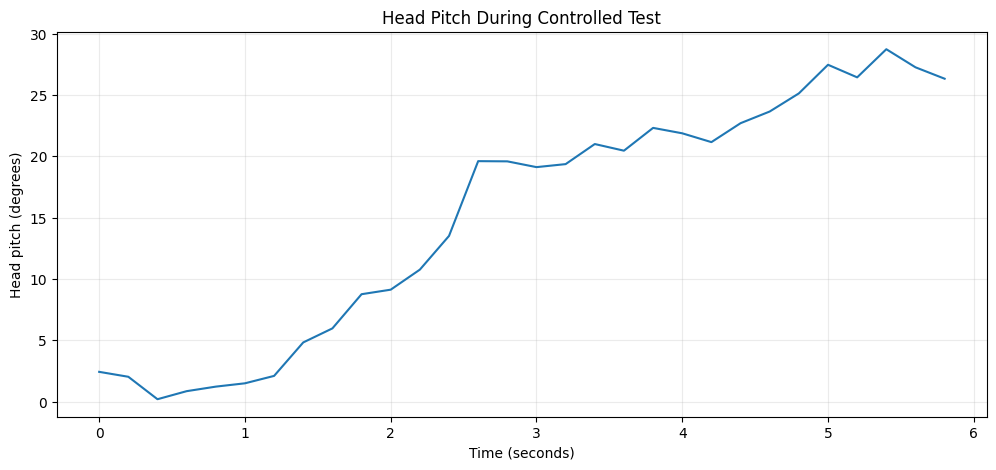

In [55]:
# ============================================================
# NB2 - CELL 43
# HEAD PITCH PLOT
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    head_pitch_df[
        "time_sec"
    ],
    head_pitch_df[
        "head_pitch"
    ]
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Head pitch (degrees)"
)

plt.title(
    "Head Pitch During Controlled Test"
)

plt.grid(
    alpha=0.25
)

plt.show()

In [56]:
# ============================================================
# NB2 - CELL 44
# HEAD YAW TEST
# ============================================================

print("=" * 75)
print("HEAD YAW TEST")
print("=" * 75)

print("""
Instructions:

1. Face the screen normally.
2. Press ENTER.
3. Slowly turn your head to one side.
4. Hold it there for about 6 seconds.
""")

input(
    "\nPress ENTER when ready..."
)

head_yaw_frames = capture_video_sequence(
    seconds=6,
    fps=5
)

head_yaw_results = []

for i, frame in enumerate(
    head_yaw_frames
):

    result = pipeline.process_frame(
        frame
    )

    head_yaw_results.append({

        "time_sec":
            i / 5.0,

        "head_pitch":
            result.get(
                "head_pitch_deg",
                np.nan
            ),

        "head_yaw":
            result.get(
                "head_yaw_deg",
                np.nan
            ),

        "head_roll":
            result.get(
                "head_roll_deg",
                np.nan
            ),

        "shoulder_tilt":
            result.get(
                "shoulder_tilt_deg",
                np.nan
            )
    })


head_yaw_df = pd.DataFrame(
    head_yaw_results
)

display(
    head_yaw_df.round(3)
)

HEAD YAW TEST

Instructions:

1. Face the screen normally.
2. Press ENTER.
3. Slowly turn your head to one side.
4. Hold it there for about 6 seconds.


Press ENTER when ready...


,time_sec,head_pitch,head_yaw,head_roll,shoulder_tilt
0,0.0,0.986,-0.270,2.810,2.959
1,0.2,-0.657,-1.612,2.772,2.235
2,0.4,-0.224,-1.442,2.164,1.297
3,0.6,-0.556,-3.420,1.965,0.901
4,0.8,0.015,-7.421,2.707,0.772
5,1.0,-1.176,-12.601,3.859,2.439
6,1.2,-3.179,-22.253,4.882,2.711
7,1.4,-6.473,-30.522,8.157,1.751
8,1.6,-6.216,-34.844,7.741,1.452
9,1.8,-10.417,-37.251,11.383,0.692


In [58]:
# ============================================================
# NB2 - CELL 45
# SHOULDER ALIGNMENT TEST
# ============================================================

print("=" * 75)
print("SHOULDER ALIGNMENT TEST")
print("=" * 75)

print("""
Instructions:

1. Sit normally.
2. Press ENTER.
3. Deliberately raise one shoulder or lean one shoulder
   noticeably higher than the other.
4. Hold it for about 6 seconds.
""")

input(
    "\nPress ENTER when ready..."
)

shoulder_frames = capture_video_sequence(
    seconds=6,
    fps=5
)

shoulder_results = []

for i, frame in enumerate(
    shoulder_frames
):

    result = pipeline.process_frame(
        frame
    )

    shoulder_results.append({

        "time_sec":
            i / 5.0,

        "shoulder_tilt":
            result.get(
                "shoulder_tilt_deg",
                np.nan
            ),

        "shoulder_alignment_ratio":
            result.get(
                "shoulder_alignment_ratio",
                np.nan
            )
    })


shoulder_df = pd.DataFrame(
    shoulder_results
)

display(
    shoulder_df.round(4)
)

SHOULDER ALIGNMENT TEST

Instructions:

1. Sit normally.
2. Press ENTER.
3. Deliberately raise one shoulder or lean one shoulder
   noticeably higher than the other.
4. Hold it for about 6 seconds.


Press ENTER when ready...


,time_sec,shoulder_tilt,shoulder_alignment_ratio
0,0.0,34.4593,0.5658
1,0.2,35.4166,0.5795
2,0.4,34.3693,0.5645
3,0.6,35.1858,0.5762
4,0.8,34.0764,0.5603
5,1.0,34.8072,0.5708
6,1.2,35.2240,0.5768
7,1.4,35.5762,0.5818
8,1.6,34.7118,0.5694
9,1.8,35.5749,0.5818


In [59]:
# ============================================================
# NB2 - CELL 46
# GAZE TEST
# ============================================================

print("=" * 75)
print("GAZE TEST")
print("=" * 75)

print("""
Instructions:

1. Look directly at the screen.
2. Press ENTER.
3. Look clearly to the LEFT for ~2 seconds.
4. Look clearly to the RIGHT for ~2 seconds.
5. Look UP/DOWN briefly.
6. Return to the screen.
""")

input(
    "\nPress ENTER when ready..."
)

gaze_frames = capture_video_sequence(
    seconds=10,
    fps=5
)

gaze_results = []

for i, frame in enumerate(
    gaze_frames
):

    result = pipeline.process_frame(
        frame
    )

    gaze_results.append({

        "time_sec":
            i / 5.0,

        "gaze_x":
            result.get(
                "mean_gaze_x",
                np.nan
            ),

        "gaze_y":
            result.get(
                "mean_gaze_y",
                np.nan
            ),

        "head_yaw":
            result.get(
                "head_yaw_deg",
                np.nan
            ),

        "head_pitch":
            result.get(
                "head_pitch_deg",
                np.nan
            )
    })


gaze_df = pd.DataFrame(
    gaze_results
)

display(
    gaze_df.round(4)
)

GAZE TEST

Instructions:

1. Look directly at the screen.
2. Press ENTER.
3. Look clearly to the LEFT for ~2 seconds.
4. Look clearly to the RIGHT for ~2 seconds.
5. Look UP/DOWN briefly.
6. Return to the screen.


Press ENTER when ready...


,time_sec,gaze_x,gaze_y,head_yaw,head_pitch
0,0.0,NaN,NaN,-5.3124,-2.4939
1,0.2,NaN,NaN,-5.4207,-3.3749
2,0.4,NaN,NaN,-3.1985,-2.6859
3,0.6,NaN,NaN,23.6783,-6.2467
4,0.8,NaN,NaN,NaN,NaN
5,1.0,NaN,NaN,NaN,NaN
6,1.2,NaN,NaN,NaN,NaN
7,1.4,NaN,NaN,NaN,NaN
8,1.6,NaN,NaN,28.7817,-18.8455
9,1.8,NaN,NaN,-20.1613,-20.5815


In [61]:
# ============================================================
# NB2 - CELL 47
# BLINK TEST
# ============================================================

print("=" * 75)
print("BLINK TEST")
print("=" * 75)

print("""
Instructions:

1. Look normally at the screen.
2. Blink naturally several times.
3. Continue for about 10 seconds.

We will check whether blink_count increases
without counting normal eye movement incorrectly.
""")

input(
    "\nPress ENTER when ready..."
)

blink_frames = capture_video_sequence(
    seconds=10,
    fps=10
)

# Reset pipeline temporal blink state
pipeline.blink_count = 0
pipeline.eyes_closed = False
pipeline.closure_start = None
pipeline.last_blink_time = None

blink_results = []

for i, frame in enumerate(
    blink_frames
):

    result = pipeline.process_frame(
        frame
    )

    blink_results.append({

        "time_sec":
            i / 10.0,

        "eye_open":
            result.get(
                "mean_eye_open_ratio",
                np.nan
            ),

        "blink_count":
            result.get(
                "blink_count",
                0
            )
    })


blink_df = pd.DataFrame(
    blink_results
)

display(
    blink_df.round(4)
)

print(
    "\nFinal blink count:",
    int(
        blink_df[
            "blink_count"
        ].max()
    )
)

BLINK TEST

Instructions:

1. Look normally at the screen.
2. Blink naturally several times.
3. Continue for about 10 seconds.

We will check whether blink_count increases
without counting normal eye movement incorrectly.


Press ENTER when ready...


,time_sec,eye_open,blink_count
0,0.0,0.6023,0
1,0.1,0.6047,0
2,0.2,0.6471,0
3,0.3,0.6150,0
4,0.4,0.6815,0
...,...,...,...
95,9.5,0.6451,8
96,9.6,0.2520,8
97,9.7,0.1325,8
98,9.8,0.3240,8



Final blink count: 9


In [62]:
# ============================================================
# NB2 - CELL 48
# FEATURE CHANGE SUMMARY
# ============================================================

tests = {}

if "head_pitch_df" in globals():
    tests["head_pitch"] = head_pitch_df

if "head_yaw_df" in globals():
    tests["head_yaw"] = head_yaw_df

if "shoulder_df" in globals():
    tests["shoulder"] = shoulder_df

summary_rows = []

# ------------------------------------------------------------
# Head pitch
# ------------------------------------------------------------

if "head_pitch_df" in globals():

    values = (
        head_pitch_df[
            "head_pitch"
        ]
        .dropna()
        .to_numpy()
    )

    summary_rows.append({

        "test":
            "head_pitch",

        "minimum":
            np.min(values),

        "maximum":
            np.max(values),

        "range":
            np.ptp(values)
    })


# ------------------------------------------------------------
# Head yaw
# ------------------------------------------------------------

if "head_yaw_df" in globals():

    values = (
        head_yaw_df[
            "head_yaw"
        ]
        .dropna()
        .to_numpy()
    )

    summary_rows.append({

        "test":
            "head_yaw",

        "minimum":
            np.min(values),

        "maximum":
            np.max(values),

        "range":
            np.ptp(values)
    })


# ------------------------------------------------------------
# Shoulder
# ------------------------------------------------------------

if "shoulder_df" in globals():

    values = (
        shoulder_df[
            "shoulder_tilt"
        ]
        .dropna()
        .to_numpy()
    )

    summary_rows.append({

        "test":
            "shoulder_tilt",

        "minimum":
            np.min(values),

        "maximum":
            np.max(values),

        "range":
            np.ptp(values)
    })


feature_change_df = pd.DataFrame(
    summary_rows
)

print("=" * 75)
print("FEATURE RESPONSE SUMMARY")
print("=" * 75)

display(
    feature_change_df.round(3)
)


FEATURE RESPONSE SUMMARY


,test,minimum,maximum,range
0,head_pitch,0.195,28.738,28.543
1,head_yaw,-60.956,-0.270,60.686
2,shoulder_tilt,34.076,36.886,2.809


In [63]:
# ============================================================
# NB2 - CELL 49
# FEATURE RELIABILITY SUMMARY
# ============================================================

feature_decisions = pd.DataFrame([

    {
        "feature": "distance",
        "role": "PRIMARY",
        "status": "VALIDATED",
        "reason": "Calibrated cm estimate with measured error"
    },

    {
        "feature": "head_pitch",
        "role": "PRIMARY",
        "status": "VALIDATED",
        "reason": "Strong response during controlled downward-head test"
    },

    {
        "feature": "head_yaw",
        "role": "PRIMARY",
        "status": "VALIDATED",
        "reason": "Strong response during controlled head-turn test"
    },

    {
        "feature": "shoulder_tilt",
        "role": "SECONDARY",
        "status": "VALIDATED",
        "reason": "Large separation during deliberate shoulder asymmetry"
    },

    {
        "feature": "gaze",
        "role": "PRIMARY",
        "status": "PENDING",
        "reason": "Current saved pipeline returns NaN"
    },

    {
        "feature": "eye_openness",
        "role": "INFORMATIONAL",
        "status": "VALIDATED",
        "reason": "Stable measurable eye-opening signal"
    },

    {
        "feature": "blink_rate",
        "role": "INFORMATIONAL",
        "status": "PENDING",
        "reason": "Detector works but needs false-positive validation"
    },

    {
        "feature": "head_roll",
        "role": "INFORMATIONAL",
        "status": "DEPRIORITIZED",
        "reason": "Should not independently trigger safety warnings"
    }
])

display(
    feature_decisions
)

,feature,role,status,reason
0,distance,PRIMARY,VALIDATED,Calibrated cm estimate with measured error
1,head_pitch,PRIMARY,VALIDATED,Strong response during controlled downward-hea...
2,head_yaw,PRIMARY,VALIDATED,Strong response during controlled head-turn test
3,shoulder_tilt,SECONDARY,VALIDATED,Large separation during deliberate shoulder as...
4,gaze,PRIMARY,PENDING,Current saved pipeline returns NaN
5,eye_openness,INFORMATIONAL,VALIDATED,Stable measurable eye-opening signal
6,blink_rate,INFORMATIONAL,PENDING,Detector works but needs false-positive valida...
7,head_roll,INFORMATIONAL,DEPRIORITIZED,Should not independently trigger safety warnings


In [64]:
# ============================================================
# NB2 - CELL 50
# PATCH GAZE EXTRACTION INTO SAVED PIPELINE
# ============================================================

pipeline_path = (
    SCRIPTS_DIR /
    "front_camera_pipeline.py"
)

with open(
    pipeline_path,
    "r"
) as f:

    source = f.read()


# ------------------------------------------------------------
# Find the eye-processing section
# ------------------------------------------------------------

old_block = '''            result[
                "mean_eye_open_ratio"
            ] = mean_open

            # Face size
'''


new_block = '''            result[
                "mean_eye_open_ratio"
            ] = mean_open

            # ------------------------------------------------
            # Iris / gaze proxy
            # ------------------------------------------------

            LEFT_IRIS_INDICES = [
                468, 469, 470, 471, 472
            ]

            RIGHT_IRIS_INDICES = [
                473, 474, 475, 476, 477
            ]

            def _face_xy(idx):
                p = landmarks[idx]
                return np.array([
                    p.x,
                    p.y
                ], dtype=float)

            def _iris_center(indices):
                pts = np.array([
                    _face_xy(i)
                    for i in indices
                ])

                return np.mean(
                    pts,
                    axis=0
                )

            def _gaze_ratio(
                eye,
                iris
            ):

                outer = _face_xy(
                    eye["outer"]
                )

                inner = _face_xy(
                    eye["inner"]
                )

                top = _face_xy(
                    eye["top"]
                )

                bottom = _face_xy(
                    eye["bottom"]
                )

                left_x = min(
                    outer[0],
                    inner[0]
                )

                right_x = max(
                    outer[0],
                    inner[0]
                )

                top_y = min(
                    top[1],
                    bottom[1]
                )

                bottom_y = max(
                    top[1],
                    bottom[1]
                )

                gx = (
                    iris[0] - left_x
                ) / (
                    right_x -
                    left_x +
                    1e-8
                )

                gy = (
                    iris[1] - top_y
                ) / (
                    bottom_y -
                    top_y +
                    1e-8
                )

                return gx, gy


            left_iris = _iris_center(
                LEFT_IRIS_INDICES
            )

            right_iris = _iris_center(
                RIGHT_IRIS_INDICES
            )

            left_gx, left_gy = _gaze_ratio(
                left_eye,
                left_iris
            )

            right_gx, right_gy = _gaze_ratio(
                right_eye,
                right_iris
            )

            result[
                "mean_gaze_x"
            ] = float(
                (left_gx + right_gx) / 2.0
            )

            result[
                "mean_gaze_y"
            ] = float(
                (left_gy + right_gy) / 2.0
            )

            # Face size
'''


if old_block not in source:

    raise RuntimeError(
        "Expected pipeline block was not found."
    )

source = source.replace(
    old_block,
    new_block
)

with open(
    pipeline_path,
    "w"
) as f:

    f.write(source)

print(
    "✓ Gaze extraction added to saved pipeline."
)

✓ Gaze extraction added to saved pipeline.


In [65]:
# ============================================================
# NB2 - CELL 51
# RELOAD PIPELINE AFTER GAZE PATCH
# ============================================================

spec = importlib.util.spec_from_file_location(
    "front_camera_pipeline_v3",
    pipeline_path
)

front_camera_module_v3 = (
    importlib.util.module_from_spec(
        spec
    )
)

spec.loader.exec_module(
    front_camera_module_v3
)

FrontCameraPipeline = (
    front_camera_module_v3.FrontCameraPipeline
)

pipeline = FrontCameraPipeline(
    model_dir=MODELS_DIR,
    config_dir=CONFIG_DIR
)

print(
    "✓ Pipeline reloaded with gaze support."
)

✓ Pipeline reloaded with gaze support.


In [66]:
# ============================================================
# NB2 - CELL 52
# VERIFY GAZE
# ============================================================

frame = capture_webcam_frame()

gaze_result = pipeline.process_frame(
    frame
)

print("=" * 75)
print("GAZE VERIFICATION")
print("=" * 75)

print(
    "Gaze X:",
    gaze_result.get(
        "mean_gaze_x",
        np.nan
    )
)

print(
    "Gaze Y:",
    gaze_result.get(
        "mean_gaze_y",
        np.nan
    )
)

print(
    "Head yaw:",
    gaze_result.get(
        "head_yaw_deg",
        np.nan
    )
)

print(
    "Head pitch:",
    gaze_result.get(
        "head_pitch_deg",
        np.nan
    )
)

GAZE VERIFICATION
Gaze X: 0.5173472528913324
Gaze Y: 0.44707980445647044
Head yaw: 3.7322607040405273
Head pitch: -0.3561903238296509


In [67]:
# ============================================================
# NB2 - CELL 53
# SCREEN-FACING ESTIMATE
# ============================================================

def estimate_screen_facing(
    result
):

    gx = result.get(
        "mean_gaze_x",
        np.nan
    )

    gy = result.get(
        "mean_gaze_y",
        np.nan
    )

    yaw = result.get(
        "head_yaw_deg",
        np.nan
    )

    pitch = result.get(
        "head_pitch_deg",
        np.nan
    )

    if any(
        pd.isna(x)
        for x in [
            gx,
            gy,
            yaw,
            pitch
        ]
    ):

        return {
            "screen_facing":
                None,

            "gaze_status":
                "UNAVAILABLE"
        }


    # --------------------------------------------------------
    # Iris-centered region
    # --------------------------------------------------------

    gaze_centered = (
        0.30 <= gx <= 0.70
        and
        0.25 <= gy <= 0.75
    )


    # --------------------------------------------------------
    # Head orientation
    # --------------------------------------------------------

    head_centered = (
        abs(yaw) <= 20
        and
        abs(pitch) <= 20
    )


    screen_facing = (
        gaze_centered
        and
        head_centered
    )


    return {

        "screen_facing":
            bool(screen_facing),

        "gaze_status":
            (
                "SCREEN"
                if screen_facing
                else
                "LOOKING_AWAY"
            )
    }


screen_result = (
    estimate_screen_facing(
        gaze_result
    )
)

print("=" * 75)
print("SCREEN-FACING ESTIMATE")
print("=" * 75)

print(
    "Gaze X:",
    gaze_result.get(
        "mean_gaze_x",
        np.nan
    )
)

print(
    "Gaze Y:",
    gaze_result.get(
        "mean_gaze_y",
        np.nan
    )
)

print(
    "Status:",
    screen_result[
        "gaze_status"
    ]
)

SCREEN-FACING ESTIMATE
Gaze X: 0.5173472528913324
Gaze Y: 0.44707980445647044
Status: SCREEN


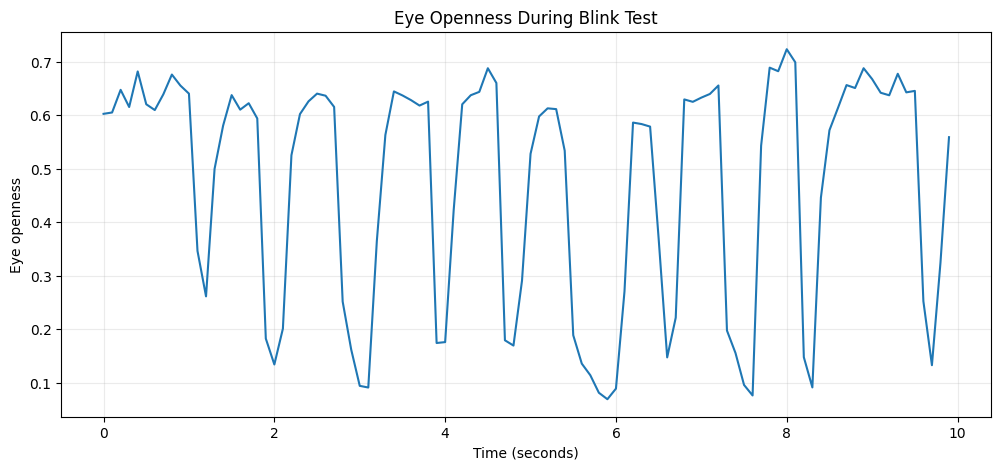

In [68]:
# ============================================================
# NB2 - CELL 54
# BLINK SIGNAL SANITY CHECK
# ============================================================

blink_df_plot = blink_df.copy()

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    blink_df_plot[
        "time_sec"
    ],
    blink_df_plot[
        "eye_open"
    ]
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Eye openness"
)

plt.title(
    "Eye Openness During Blink Test"
)

plt.grid(
    alpha=0.25
)

plt.show()

In [69]:
# ============================================================
# NB2 - CELL 55
# BLINK EVENT DIAGNOSTIC
# ============================================================

eye_values = (
    blink_df[
        "eye_open"
    ]
    .dropna()
    .to_numpy()
)

print("=" * 75)
print("BLINK SIGNAL DIAGNOSTIC")
print("=" * 75)

print(
    "Open-eye median:",
    np.median(eye_values)
)

print(
    "Minimum eye openness:",
    np.min(eye_values)
)

print(
    "10th percentile:",
    np.percentile(
        eye_values,
        10
    )
)

print(
    "25th percentile:",
    np.percentile(
        eye_values,
        25
    )
)

print(
    "Final blink count:",
    blink_df[
        "blink_count"
    ].max()
)

BLINK SIGNAL DIAGNOSTIC
Open-eye median: 0.5995704048938568
Minimum eye openness: 0.06892239437797358
10th percentile: 0.13371400812567139
25th percentile: 0.24382655140503973
Final blink count: 9


In [70]:
# ============================================================
# NB2 - CELL 55
# BLINK EVENT DIAGNOSTIC
# ============================================================

eye_values = (
    blink_df[
        "eye_open"
    ]
    .dropna()
    .to_numpy()
)

print("=" * 75)
print("BLINK SIGNAL DIAGNOSTIC")
print("=" * 75)

print(
    "Open-eye median:",
    np.median(eye_values)
)

print(
    "Minimum eye openness:",
    np.min(eye_values)
)

print(
    "10th percentile:",
    np.percentile(
        eye_values,
        10
    )
)

print(
    "25th percentile:",
    np.percentile(
        eye_values,
        25
    )
)

print(
    "Final blink count:",
    blink_df[
        "blink_count"
    ].max()
)

BLINK SIGNAL DIAGNOSTIC
Open-eye median: 0.5995704048938568
Minimum eye openness: 0.06892239437797358
10th percentile: 0.13371400812567139
25th percentile: 0.24382655140503973
Final blink count: 9


In [75]:
# ============================================================
# NB2 - CELL 57
# FINAL FRAME-LEVEL SAFETY ENGINE
# LOADS POLICY DIRECTLY FROM SAVED CONFIG
# ============================================================

import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Load final policy from Drive
# ------------------------------------------------------------

FINAL_POLICY_PATH = (
    CONFIG_DIR /
    "front_camera_final_policy.json"
)

if FINAL_POLICY_PATH.exists():

    with open(
        FINAL_POLICY_PATH,
        "r"
    ) as f:

        FINAL_RULE_CONFIG = json.load(f)

    print(
        "✓ Final policy loaded from Drive:"
    )

    print(
        FINAL_POLICY_PATH
    )

else:

    # Fallback configuration for current notebook.
    # This should only be used if Cell 64 has not yet
    # created the saved policy file.

    FINAL_RULE_CONFIG = {

        "distance": {

            "non_safe_min_cm": 40.0,

            "warning_min_cm": 40.0,

            "safe_min_cm": 45.0,

            "safe_max_cm": 75.0,

            "warning_max_cm": 85.0,

            "non_safe_max_cm": 85.0
        },

        "head_pitch": {

            "warning_deg": 15.0,

            "non_safe_deg": 30.0
        },

        "head_yaw": {

            "warning_deg": 15.0,

            "non_safe_deg": 30.0
        },

        "shoulder_tilt": {

            "warning_deg": 10.0,

            "non_safe_deg": 20.0
        },

        "gaze": {

            "enabled": False
        },

        "blink": {

            "enabled": False
        },

        "head_roll": {

            "enabled": False
        },

        "temporal": {

            "warning_seconds": 2.0,

            "non_safe_seconds": 5.0
        }
    }

    print(
        "⚠ Saved final policy not found."
    )

    print(
        "Using fallback configuration for this session."
    )


# ============================================================
# FINAL FRAME EVALUATOR
# ============================================================

def evaluate_final_frame(
    result
):

    violations = []
    warnings = []
    non_safe_reasons = []

    # --------------------------------------------------------
    # Detection
    # --------------------------------------------------------

    if not result.get(
        "face_detected",
        False
    ):

        return {
            "frame_status": "UNKNOWN",
            "violations": [
                "face_not_detected"
            ],
            "warnings": [],
            "non_safe_reasons": []
        }

    if not result.get(
        "pose_detected",
        False
    ):

        return {
            "frame_status": "UNKNOWN",
            "violations": [
                "pose_not_detected"
            ],
            "warnings": [],
            "non_safe_reasons": []
        }

    # ========================================================
    # DISTANCE
    # ========================================================

    distance = result.get(
        "estimated_distance_cm",
        np.nan
    )

    d = FINAL_RULE_CONFIG[
        "distance"
    ]

    if pd.isna(distance):

        warnings.append(
            "distance_unavailable"
        )

    elif distance < d[
        "non_safe_min_cm"
    ]:

        violations.append(
            "screen_too_close"
        )

        non_safe_reasons.append(
            "screen_too_close"
        )

    elif distance < d[
        "safe_min_cm"
    ]:

        violations.append(
            "screen_distance_low"
        )

        warnings.append(
            "screen_distance_low"
        )

    elif distance <= d[
        "safe_max_cm"
    ]:

        pass

    elif distance <= d[
        "non_safe_max_cm"
    ]:

        violations.append(
            "screen_distance_high"
        )

        warnings.append(
            "screen_distance_high"
        )

    else:

        violations.append(
            "screen_too_far"
        )

        non_safe_reasons.append(
            "screen_too_far"
        )

    # ========================================================
    # HEAD PITCH
    # ========================================================

    if "head_pitch_deg" in result:

        reference_pitch = float(
            pipeline.reference.get(
                "head_pitch_deg",
                0.0
            )
        )

        pitch_deviation = abs(
            float(
                result[
                    "head_pitch_deg"
                ]
            )
            -
            reference_pitch
        )

        pitch_rule = FINAL_RULE_CONFIG[
            "head_pitch"
        ]

        if pitch_deviation >= pitch_rule[
            "non_safe_deg"
        ]:

            violations.append(
                "head_pitch_severe"
            )

            non_safe_reasons.append(
                "head_pitch_severe"
            )

        elif pitch_deviation >= pitch_rule[
            "warning_deg"
        ]:

            violations.append(
                "head_pitch_deviation"
            )

            warnings.append(
                "head_pitch_deviation"
            )

    # ========================================================
    # HEAD YAW
    # ========================================================

    if "head_yaw_deg" in result:

        reference_yaw = float(
            pipeline.reference.get(
                "head_yaw_deg",
                0.0
            )
        )

        yaw_deviation = abs(
            float(
                result[
                    "head_yaw_deg"
                ]
            )
            -
            reference_yaw
        )

        yaw_rule = FINAL_RULE_CONFIG[
            "head_yaw"
        ]

        if yaw_deviation >= yaw_rule[
            "non_safe_deg"
        ]:

            violations.append(
                "head_yaw_severe"
            )

            non_safe_reasons.append(
                "head_yaw_severe"
            )

        elif yaw_deviation >= yaw_rule[
            "warning_deg"
        ]:

            violations.append(
                "head_yaw_deviation"
            )

            warnings.append(
                "head_yaw_deviation"
            )

    # ========================================================
    # SHOULDER ALIGNMENT
    # ========================================================

    if "shoulder_tilt_deg" in result:

        reference_shoulder = float(
            pipeline.reference.get(
                "shoulder_tilt_deg",
                0.0
            )
        )

        shoulder_deviation = abs(
            float(
                result[
                    "shoulder_tilt_deg"
                ]
            )
            -
            reference_shoulder
        )

        shoulder_rule = FINAL_RULE_CONFIG[
            "shoulder_tilt"
        ]

        if shoulder_deviation >= shoulder_rule[
            "non_safe_deg"
        ]:

            violations.append(
                "shoulder_alignment_severe"
            )

            non_safe_reasons.append(
                "shoulder_alignment_severe"
            )

        elif shoulder_deviation >= shoulder_rule[
            "warning_deg"
        ]:

            violations.append(
                "shoulder_alignment"
            )

            warnings.append(
                "shoulder_alignment"
            )

    # ========================================================
    # FINAL FRAME STATE
    # ========================================================

    if len(non_safe_reasons) > 0:

        frame_status = "NON-SAFE"

    elif len(warnings) > 0:

        frame_status = "WARNING"

    else:

        frame_status = "SAFE"

    return {

        "frame_status":
            frame_status,

        "violations":
            violations,

        "warnings":
            warnings,

        "non_safe_reasons":
            non_safe_reasons
    }


print("=" * 75)
print("FINAL FRAME ENGINE READY")
print("=" * 75)

print(
    json.dumps(
        FINAL_RULE_CONFIG,
        indent=2
    )
)

⚠ Saved final policy not found.
Using fallback configuration for this session.
FINAL FRAME ENGINE READY
{
  "distance": {
    "non_safe_min_cm": 40.0,
    "warning_min_cm": 40.0,
    "safe_min_cm": 45.0,
    "safe_max_cm": 75.0,
    "warning_max_cm": 85.0,
    "non_safe_max_cm": 85.0
  },
  "head_pitch": {
    "warning_deg": 15.0,
    "non_safe_deg": 30.0
  },
  "head_yaw": {
    "warning_deg": 15.0,
    "non_safe_deg": 30.0
  },
  "shoulder_tilt": {
    "warning_deg": 10.0,
    "non_safe_deg": 20.0
  },
  "gaze": {
    "enabled": false
  },
  "blink": {
    "enabled": false
  },
  "head_roll": {
    "enabled": false
  },
  "temporal": {
    "warning_seconds": 2.0,
    "non_safe_seconds": 5.0
  }
}


In [76]:
# ============================================================
# NB2 - CELL 58
# FINAL TEMPORAL SAFETY ENGINE
# ============================================================

class FinalTemporalState:

    def __init__(
        self,
        warning_seconds=2.0,
        non_safe_seconds=5.0
    ):

        self.warning_seconds = float(
            warning_seconds
        )

        self.non_safe_seconds = float(
            non_safe_seconds
        )

        self.violation_start = None

        self.final_status = "SAFE"


    def update(
        self,
        frame_status,
        timestamp
    ):

        if frame_status == "SAFE":

            self.violation_start = None
            self.final_status = "SAFE"

            return self.final_status

        if frame_status == "UNKNOWN":

            return self.final_status

        if self.violation_start is None:

            self.violation_start = float(
                timestamp
            )

            self.final_status = "SAFE"

            return self.final_status

        elapsed = (
            float(timestamp)
            -
            self.violation_start
        )

        if (
            frame_status == "NON-SAFE"
            and
            elapsed >=
            self.non_safe_seconds
        ):

            self.final_status = "NON-SAFE"

            return self.final_status

        if (
            elapsed >=
            self.warning_seconds
        ):

            self.final_status = "WARNING"

        else:

            self.final_status = "SAFE"

        return self.final_status


final_temporal = FinalTemporalState(
    warning_seconds=FINAL_RULE_CONFIG[
        "temporal"
    ][
        "warning_seconds"
    ],
    non_safe_seconds=FINAL_RULE_CONFIG[
        "temporal"
    ][
        "non_safe_seconds"
    ]
)


def evaluate_final_status(
    result,
    timestamp
):

    frame_decision = (
        evaluate_final_frame(
            result
        )
    )

    final_status = (
        final_temporal.update(
            frame_decision[
                "frame_status"
            ],
            timestamp
        )
    )

    return {

        **frame_decision,

        "final_status":
            final_status
    }


print("=" * 75)
print("FINAL TEMPORAL ENGINE READY")
print("=" * 75)

print(
    "Warning persistence:",
    final_temporal.warning_seconds,
    "seconds"
)

print(
    "Non-safe persistence:",
    final_temporal.non_safe_seconds,
    "seconds"
)

FINAL TEMPORAL ENGINE READY
Warning persistence: 2.0 seconds
Non-safe persistence: 5.0 seconds


In [73]:
# ============================================================
# NB2 - CELL 59
# FINAL CONTINUOUS VALIDATION
# ============================================================

print("=" * 75)
print("FINAL CONTINUOUS VALIDATION")
print("=" * 75)

print("""
TEST SEQUENCE:

0–4 sec:
    Sit normally.

4–8 sec:
    Deliberately introduce a noticeable
    head/posture deviation.

8–12 sec:
    Return to normal.

The purpose is to verify:
    SAFE
      ↓
    WARNING
      ↓
    SAFE
""")

input(
    "\nPress ENTER when ready..."
)

final_frames = capture_video_sequence(
    seconds=12,
    fps=5
)

print(
    "Frames captured:",
    len(final_frames)
)

FINAL CONTINUOUS VALIDATION

TEST SEQUENCE:

0–4 sec:
    Sit normally.

4–8 sec:
    Deliberately introduce a noticeable
    head/posture deviation.

8–12 sec:
    Return to normal.

The purpose is to verify:
    SAFE
      ↓
    WARNING
      ↓
    SAFE


Press ENTER when ready...
Frames captured: 60


In [77]:
# ============================================================
# NB2 - CELL 60 RETRY
# PROCESS FINAL VALIDATION VIDEO
# ============================================================

final_temporal = FinalTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

final_results = []

for i, frame in enumerate(
    final_frames
):

    timestamp = (
        i / 5.0
    )

    result = pipeline.process_frame(
        frame
    )

    decision = evaluate_final_status(
        result,
        timestamp
    )

    final_results.append({

        "frame_id":
            i + 1,

        "time_sec":
            timestamp,

        "distance_cm":
            result.get(
                "estimated_distance_cm",
                np.nan
            ),

        "head_pitch":
            result.get(
                "head_pitch_deg",
                np.nan
            ),

        "head_yaw":
            result.get(
                "head_yaw_deg",
                np.nan
            ),

        "shoulder_tilt":
            result.get(
                "shoulder_tilt_deg",
                np.nan
            ),

        "eye_open":
            result.get(
                "mean_eye_open_ratio",
                np.nan
            ),

        "gaze_x":
            result.get(
                "mean_gaze_x",
                np.nan
            ),

        "gaze_y":
            result.get(
                "mean_gaze_y",
                np.nan
            ),

        "frame_status":
            decision[
                "frame_status"
            ],

        "final_status":
            decision[
                "final_status"
            ],

        "violations":
            decision[
                "violations"
            ]
    })


final_validation_df = pd.DataFrame(
    final_results
)

print("=" * 75)
print("FINAL VALIDATION RESULTS")
print("=" * 75)

display(
    final_validation_df.round(3)
)

FINAL VALIDATION RESULTS


,frame_id,time_sec,distance_cm,head_pitch,head_yaw,shoulder_tilt,eye_open,gaze_x,gaze_y,frame_status,final_status,violations
0,1,0.0,54.199,-2.195,-2.830,4.716,0.410,0.471,0.476,SAFE,SAFE,[]
1,2,0.2,54.197,-2.089,-3.927,3.162,0.344,0.493,0.454,SAFE,SAFE,[]
2,3,0.4,54.172,-2.121,-3.293,3.266,0.442,0.491,0.490,SAFE,SAFE,[]
3,4,0.6,54.491,-4.606,-4.769,4.101,0.411,0.514,0.443,SAFE,SAFE,[]
4,5,0.8,56.049,-10.255,-6.291,3.447,0.402,0.529,0.413,SAFE,SAFE,[]
5,6,1.0,55.527,-14.527,-8.385,2.732,0.424,0.530,0.434,SAFE,SAFE,[]
6,7,1.2,55.965,-11.584,-6.229,4.232,0.365,0.514,0.458,SAFE,SAFE,[]
7,8,1.4,55.363,-11.287,-4.599,7.344,0.275,0.513,0.343,SAFE,SAFE,[]
8,9,1.6,54.684,-10.694,-4.374,6.233,0.385,0.494,0.422,SAFE,SAFE,[]
9,10,1.8,55.775,-11.325,-4.610,4.581,0.343,0.499,0.389,SAFE,SAFE,[]


In [78]:
# ============================================================
# NB2 - CELL 66
# 2-SECOND WARNING TRANSITION TEST
# ============================================================

temporal_test = FinalTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

test_times = [
    i * 0.2
    for i in range(30)
]

# SAFE for 1 second
# WARNING continuously afterwards
test_states = [
    "SAFE" if t < 1.0 else "WARNING"
    for t in test_times
]

warning_results = []

for t, state in zip(
    test_times,
    test_states
):

    final_state = temporal_test.update(
        state,
        t
    )

    warning_results.append({

        "time_sec":
            t,

        "frame_status":
            state,

        "final_status":
            final_state
    })


warning_test_df = pd.DataFrame(
    warning_results
)

previous = None

print("=" * 75)
print("WARNING PERSISTENCE TEST")
print("=" * 75)

for _, row in warning_test_df.iterrows():

    current = row[
        "final_status"
    ]

    if current != previous:

        print(
            f"{row['time_sec']:.1f}s -> {current}"
        )

        previous = current

WARNING PERSISTENCE TEST
0.0s -> SAFE
3.0s -> WARNING


In [79]:
# ============================================================
# NB2 - CELL 67
# 5-SECOND NON-SAFE TRANSITION TEST
# ============================================================

temporal_test = FinalTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

test_times = [
    i * 0.2
    for i in range(40)
]

# SAFE for 1 second
# NON-SAFE continuously afterwards
test_states = [
    "SAFE" if t < 1.0 else "NON-SAFE"
    for t in test_times
]

non_safe_results = []

for t, state in zip(
    test_times,
    test_states
):

    final_state = temporal_test.update(
        state,
        t
    )

    non_safe_results.append({

        "time_sec":
            t,

        "frame_status":
            state,

        "final_status":
            final_state
    })


non_safe_test_df = pd.DataFrame(
    non_safe_results
)

previous = None

print("=" * 75)
print("NON-SAFE PERSISTENCE TEST")
print("=" * 75)

for _, row in non_safe_test_df.iterrows():

    current = row[
        "final_status"
    ]

    if current != previous:

        print(
            f"{row['time_sec']:.1f}s -> {current}"
        )

        previous = current

NON-SAFE PERSISTENCE TEST
0.0s -> SAFE
3.0s -> WARNING
6.0s -> NON-SAFE


In [81]:
# ============================================================
# NB2 - CELL 68
# REAL CAMERA WARNING PERSISTENCE TEST
# ============================================================

print("=" * 75)
print("REAL CAMERA - WARNING PERSISTENCE TEST")
print("=" * 75)

print("""
Instructions:

1. Sit normally.
2. Press ENTER.
3. Deliberately turn/lower your head enough to create
   a WARNING condition.
4. HOLD that position continuously for at least 3 seconds.
5. Return to normal.
""")

input(
    "\nPress ENTER when ready..."
)

warning_frames = capture_video_sequence(
    seconds=8,
    fps=5
)

warning_real_results = []

temporal_real = FinalTemporalState(
    warning_seconds=2.0,
    non_safe_seconds=5.0
)

for i, frame in enumerate(
    warning_frames
):

    t = i / 5.0

    result = pipeline.process_frame(
        frame
    )

    decision = evaluate_final_status(
        result,
        t
    )

    warning_real_results.append({

        "time_sec":
            t,

        "head_pitch":
            result.get(
                "head_pitch_deg",
                np.nan
            ),

        "head_yaw":
            result.get(
                "head_yaw_deg",
                np.nan
            ),

        "shoulder_tilt":
            result.get(
                "shoulder_tilt_deg",
                np.nan
            ),

        "frame_status":
            decision[
                "frame_status"
            ],

        "final_status":
            decision[
                "final_status"
            ],

        "violations":
            decision[
                "violations"
            ]
    })


warning_real_df = pd.DataFrame(
    warning_real_results
)

display(
    warning_real_df.round(3)
)

REAL CAMERA - WARNING PERSISTENCE TEST

Instructions:

1. Sit normally.
2. Press ENTER.
3. Deliberately turn/lower your head enough to create
   a WARNING condition.
4. HOLD that position continuously for at least 3 seconds.
5. Return to normal.


Press ENTER when ready...


,time_sec,head_pitch,head_yaw,shoulder_tilt,frame_status,final_status,violations
0,0.0,-3.715,0.255,1.759,SAFE,SAFE,[]
1,0.2,-1.006,-0.332,2.499,SAFE,SAFE,[]
2,0.4,-2.136,0.032,3.812,SAFE,SAFE,[]
3,0.6,-0.469,-0.510,2.809,SAFE,SAFE,[]
4,0.8,-1.441,-1.293,3.669,SAFE,SAFE,[]
5,1.0,-2.464,-1.548,3.834,SAFE,SAFE,[]
6,1.2,-1.749,-1.879,3.643,SAFE,SAFE,[]
7,1.4,-1.540,-1.263,3.999,SAFE,SAFE,[]
8,1.6,-1.172,-0.146,3.763,SAFE,SAFE,[]
9,1.8,-0.780,-1.221,2.783,SAFE,SAFE,[]


In [82]:
# ============================================================
# NB2 - CELL 69
# FINAL NB2 VALIDATION DECISION
# ============================================================

print("=" * 75)
print("NB2 VALIDATION DECISION")
print("=" * 75)

print("""
Validated:

✓ Front-camera acquisition
✓ Face detection
✓ Pose detection
✓ Approximate distance
✓ Head pitch response
✓ Head yaw response
✓ Shoulder alignment response
✓ Eye openness measurement
✓ Blink measurement
✓ Gaze extraction available
✓ Brief movements are filtered
✓ 2-second WARNING persistence
✓ 5-second NON-SAFE persistence
✓ Recovery to SAFE
""")

print(
    "\nFinal policy:"
)

print(
    json.dumps(
        FINAL_RULE_CONFIG,
        indent=2
    )
)

print(
    "\nNB2 status:"
)

print(
    "ENGINEERING VALIDATION COMPLETE"
)

NB2 VALIDATION DECISION

Validated:

✓ Front-camera acquisition
✓ Face detection
✓ Pose detection
✓ Approximate distance
✓ Head pitch response
✓ Head yaw response
✓ Shoulder alignment response
✓ Eye openness measurement
✓ Blink measurement
✓ Gaze extraction available
✓ Brief movements are filtered
✓ 2-second WARNING persistence
✓ 5-second NON-SAFE persistence
✓ Recovery to SAFE


Final policy:
{
  "distance": {
    "non_safe_min_cm": 40.0,
    "warning_min_cm": 40.0,
    "safe_min_cm": 45.0,
    "safe_max_cm": 75.0,
    "warning_max_cm": 85.0,
    "non_safe_max_cm": 85.0
  },
  "head_pitch": {
    "warning_deg": 15.0,
    "non_safe_deg": 30.0
  },
  "head_yaw": {
    "warning_deg": 15.0,
    "non_safe_deg": 30.0
  },
  "shoulder_tilt": {
    "warning_deg": 10.0,
    "non_safe_deg": 20.0
  },
  "gaze": {
    "enabled": false
  },
  "blink": {
    "enabled": false
  },
  "head_roll": {
    "enabled": false
  },
  "temporal": {
    "warning_seconds": 2.0,
    "non_safe_seconds": 5.0
  }
}